# EDA Checklist Before Modelling

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\maxan\OneDrive\Desktop\0. Personal Projects\market-intelligence-pipeline")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

## 1. Create EDA notebook
- [ ] Create notebooks/01_eda.ipynb
- [ ] Load price_features from DuckDB
- [ ] Sort by ticker, date
- [ ] Confirm row count and column count
- [ ] Confirm date range
- [ ] Confirm tickers included

In [3]:
import pandas as pd
import numpy as np
import duckdb

from src.config import (
    DATABASE_PATH,
    ROLLING_WINDOWS,
    LAGGED_WINDOWS,
    MA_WINDOWS,
    TICKERS,
    START_DATE,
    END_DATE
)

from src.features import (
    build_price_feature_columns
)

CALENDAR = "no_calendar"


def pull_calendar_table(table_name: str, calendar: str) -> pd.DataFrame:

    print("[START] Connecting to database...")

    con = duckdb.connect(DATABASE_PATH)

    print(f"[START] Reading {table_name}")

    df = con.sql(f"""
    
        SELECT *
        FROM {table_name}

    """).df()

    print(f"[DONE] Read {table_name}")

    con.close()

    print(f"[START] Building {CALENDAR} required columns...")

    base_cols = [
        "ticker",
        "date",
        "open",
        "high",
        "low",
        "close",
        "adj_close",
        "volume"
    ]

    feature_columns = build_price_feature_columns(
        calendars = [CALENDAR],
        rolling_windows = ROLLING_WINDOWS,
        lagged_windows = LAGGED_WINDOWS,
        ma_windows = MA_WINDOWS
    )

    expected_columns = base_cols + list(feature_columns.keys())

    calendar_df = df[expected_columns].copy()

    print(f"[DONE] Filtered to {CALENDAR}")

    return calendar_df

In [4]:
# Load price_features from DuckDB

df = pull_calendar_table(
    table_name = "price_features", 
    calendar = CALENDAR
    )

print(f"[STEP] Loaded price_features table selecting {CALENDAR} columns")
print(df.head(10))

[START] Connecting to database...
[START] Reading price_features
[DONE] Read price_features
[START] Building no_calendar required columns...
[DONE] Filtered to no_calendar
[STEP] Loaded price_features table selecting no_calendar columns
  ticker       date        open        high         low       close  \
0    GLD 2018-01-02  124.660004  125.180000  124.389999  125.150002   
1    GLD 2018-01-03  125.050003  125.089996  124.099998  124.820000   
2    GLD 2018-01-08  125.199997  125.320000  124.900002  125.309998   
3    GLD 2018-03-01  124.150002  125.309998  123.580002  124.720001   
4    GLD 2018-03-09  124.940002  125.690002  124.779999  125.540001   
5    GLD 2018-03-12  125.040001  125.570000  124.839996  125.540001   
6    GLD 2018-03-22  126.089996  126.339996  125.639999  125.980003   
7    GLD 2018-04-05  125.449997  126.080002  125.430000  125.800003   
8    GLD 2018-04-24  125.779999  126.339996  125.669998  126.230003   
9    GLD 2018-04-25  125.230003  125.510002  125.0599

In [5]:
# Sort by ticker, date.

df = df.sort_values(["ticker", "date"]).reset_index(drop = True)

print("[STEP] Sorted by ticker, date")
print(df.head(10))

[STEP] Sorted by ticker, date
  ticker       date        open        high         low       close  \
0    GLD 2018-01-02  124.660004  125.180000  124.389999  125.150002   
1    GLD 2018-01-03  125.050003  125.089996  124.099998  124.820000   
2    GLD 2018-01-04  124.889999  125.849998  124.739998  125.459999   
3    GLD 2018-01-05  124.930000  125.480003  124.830002  125.330002   
4    GLD 2018-01-08  125.199997  125.320000  124.900002  125.309998   
5    GLD 2018-01-09  124.489998  124.860001  124.230003  124.730003   
6    GLD 2018-01-10  125.169998  125.309998  124.720001  125.029999   
7    GLD 2018-01-11  125.370003  125.660004  125.250000  125.440002   
8    GLD 2018-01-12  126.010002  127.129997  125.809998  126.959999   
9    GLD 2018-01-16  126.599998  127.180000  126.400002  127.169998   

    adj_close    volume  daily_return_no_calendar  log_return_no_calendar  \
0  125.150002  11762500                       NaN                     NaN   
1  124.820000   7904300           

In [6]:
# Confirm row count and column count

shape = df.shape

print(f"Row count: {shape[0]}")
print(f"Column count: {shape[1]}")

Row count: 11534
Column count: 23


In [7]:
# Confirm date range

max_date = df["date"].dt.date.max()
min_date = df["date"].dt.date.min()

print(f"Date range: {min_date} -> {max_date}")

print(f"CONFIG Date range: {START_DATE} -> {END_DATE}")

print(f"""
Yfinance pulls dates one day after CONFIG START_DATE
and CONFIG END_DATE when set to None pulls data till today
""")

Date range: 2018-01-02 -> 2026-06-30
CONFIG Date range: 2018-01-01 -> None

Yfinance pulls dates one day after CONFIG START_DATE
and CONFIG END_DATE when set to None pulls data till today



In [8]:
# Confirm tickers included

tickers = df["ticker"].unique().tolist()

print(f"Tickers included: {sorted(tickers)}")

print(f"\nCONFIG Tickers: {sorted(TICKERS)}")

Tickers included: ['GLD', 'MU', 'NKE', 'RPI.L', 'SNDK', 'SPY', 'TLT']

CONFIG Tickers: ['GLD', 'MU', 'NKE', 'RPI.L', 'SNDK', 'SPY', 'TLT']


## 2. Data quality checks
- [ ] Check missing values by column
- [ ] Check missing values by ticker
- [ ] Check duplicate ticker + date rows
- [ ] Check infinite values
- [ ] Check zero/negative prices
- [ ] Check date gaps per ticker
- [ ] Check whether all tickers have enough history
- [ ] Check target columns have expected nulls at the final row per ticker

In [9]:
# Missing values by column

print("Number of missing values per column:")

df.isna().sum()

Number of missing values per column:


ticker                                  0
date                                    0
open                                    0
high                                    0
low                                     0
close                                   0
adj_close                               0
volume                                  0
daily_return_no_calendar                7
log_return_no_calendar                  7
cumulative_returns_no_calendar          7
rolling_7d_return_no_calendar          49
rolling_30d_return_no_calendar        210
lag_1_return_no_calendar               14
lag_5_return_no_calendar               42
moving_avg_20_no_calendar             133
moving_avg_50_no_calendar             343
price_vs_ma20_no_calendar             133
relative_volume_no_calendar           133
rolling_30d_volatility_no_calendar    210
drawdown_no_calendar                    0
target_next_day_return_no_calendar      7
target_direction_no_calendar            7
dtype: int64

In [10]:
# Missing values by ticker

print("Missing values by ticker:")

df.groupby("ticker").apply(lambda g: g.isna().sum().sum())

Missing values by ticker:


ticker
GLD      186
MU       186
NKE      186
RPI.L    186
SNDK     186
SPY      186
TLT      186
dtype: int64

In [11]:
# Check duplicate ticker + date rows

print("Number of duplicate ticker, date rows: ", df.duplicated(subset=["ticker", "date"]).sum())

Number of duplicate ticker, date rows:  0


In [12]:
# Check infinite values

numeric_df = df.select_dtypes(include="number")

total_inf = np.isinf(numeric_df).sum()

print("Number of infinite values in numerical columns:")

print(total_inf)

Number of infinite values in numerical columns:
open                                  0
high                                  0
low                                   0
close                                 0
adj_close                             0
volume                                0
daily_return_no_calendar              0
log_return_no_calendar                0
cumulative_returns_no_calendar        0
rolling_7d_return_no_calendar         0
rolling_30d_return_no_calendar        0
lag_1_return_no_calendar              0
lag_5_return_no_calendar              0
moving_avg_20_no_calendar             0
moving_avg_50_no_calendar             0
price_vs_ma20_no_calendar             0
relative_volume_no_calendar           0
rolling_30d_volatility_no_calendar    0
drawdown_no_calendar                  0
target_next_day_return_no_calendar    0
target_direction_no_calendar          0
dtype: Int64


In [13]:
# Check zero / negative prices:

price_df = df[["open", "high", "low", "close", "adj_close"]]

zero_negative_count = (price_df <= 0).sum().sum()

print(f"Number of zero or negative prices: {zero_negative_count}")

Number of zero or negative prices: 0


In [14]:
# Check date gaps per ticker:

group_col = "ticker"
date_col = "date"

date_gap_df = df.copy()

## Convert date to date time format just in case is text.
date_gap_df[date_col] = pd.to_datetime(date_gap_df[date_col])

## Sort by ticker then date just in case.
date_gap_df = date_gap_df.sort_values([group_col, date_col])

## Get previous date from wihtin each group by shifting date down.
date_gap_df["previous_date"] = date_gap_df.groupby(group_col)[date_col].shift()

## Calculate date gap between sequential rows.
date_gap_df["gap"] = date_gap_df[date_col] - date_gap_df["previous_date"]

## Identify any gap bigger than a 1 day gap.
gaps = date_gap_df[date_gap_df["gap"] > pd.Timedelta(days=1)]

## Count gaps per ticker
gap_count = gaps.groupby(group_col).size()

print("Number of date gaps per ticker:")
print(gap_count)

Number of date gaps per ticker:
ticker
GLD      467
MU       467
NKE      467
RPI.L    110
SNDK      76
SPY      467
TLT      467
dtype: int64


In [15]:
# Check sufficent data per ticker?

df_history = df.copy()

date_col = "date"
group_col = "ticker"

## Ensure date time format
df_history[date_col] = pd.to_datetime(df_history[date_col])

## Count rows per ticker
df_history.groupby(group_col).size()

## Create summary dataframe per ticker
history_summary = (
    df_history.groupby(group_col)
    .agg(
        first_date = ("date", "min"),
        last_date = ("date", "max"),
        observations = ("date", "size")
    )
)

## Create list of rolling windows
windows = ROLLING_WINDOWS + LAGGED_WINDOWS + MA_WINDOWS

## Define sufficeint date as 2*max window
history_summary["sufficient_data"] = history_summary["observations"] > (2 * max(windows))

history_summary = history_summary.sort_values("observations")

history_summary


,first_date,last_date,observations,sufficient_data
ticker,,,,
SNDK,2025-02-13,2026-06-30,345,True
RPI.L,2024-06-11,2026-06-30,519,True
MU,2018-01-02,2026-06-30,2134,True
GLD,2018-01-02,2026-06-30,2134,True
NKE,2018-01-02,2026-06-30,2134,True
SPY,2018-01-02,2026-06-30,2134,True
TLT,2018-01-02,2026-06-30,2134,True


In [16]:
# Check target columns have expected nulls at final row per ticker

## Select columsn that contain ticker or target
target_df = df.loc[:, df.columns.str.contains("target|ticker", case=False)]

## Select last row per group to inspect
target_df.groupby("ticker").tail(1)

,ticker,target_next_day_return_no_calendar,target_direction_no_calendar
2133,GLD,NaN,<NA>
4267,MU,NaN,<NA>
6401,NKE,NaN,<NA>
6920,RPI.L,NaN,<NA>
7265,SNDK,NaN,<NA>
9399,SPY,NaN,<NA>
11533,TLT,NaN,<NA>


## 3. Price behaviour
- [ ] Plot adjusted close over time per ticker
- [ ] Compare normalized prices starting at 100
- [ ] Identify major price jumps or drops
- [ ] Check whether any ticker behaves unusually
- [ ] Write 2–3 observations

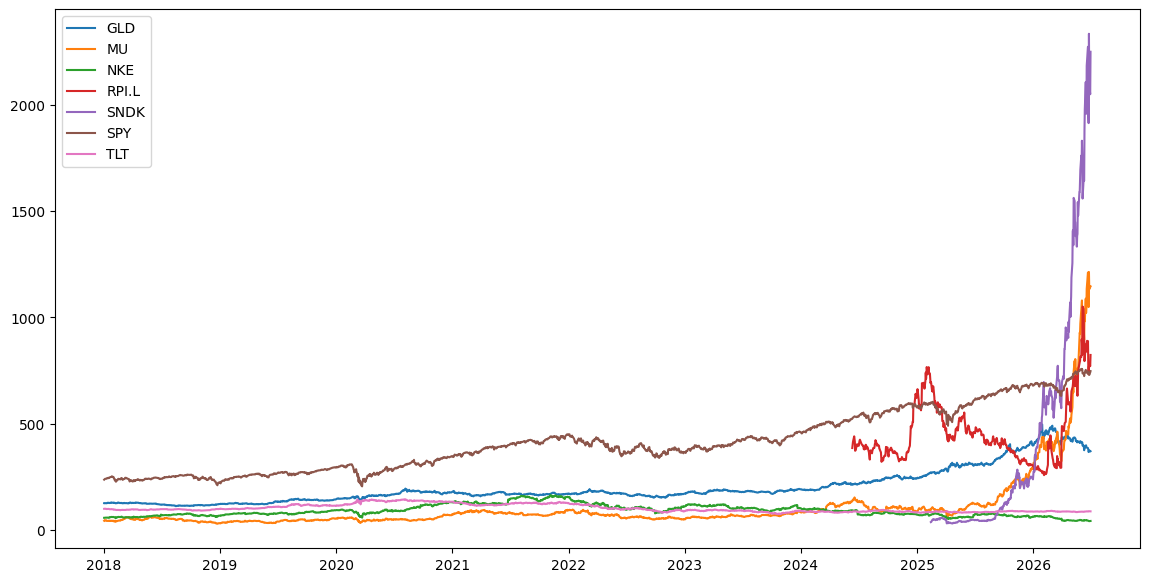

In [17]:
# Plot adjusted close over time per ticker:

import matplotlib.pyplot as plt

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["ticker", "date"])

plt.figure(figsize=(14, 7))
# Spit the data into groups.
# Go through each ticker one at a time.
for ticker, group in df.groupby("ticker"):
    plt.plot(group["date"], group["adj_close"], label=ticker)

plt.legend()
plt.show()

[START] Connecting to database...
[START] Reading price_features
[DONE] Read price_features
[START] Building no_calendar required columns...
[DONE] Filtered to no_calendar


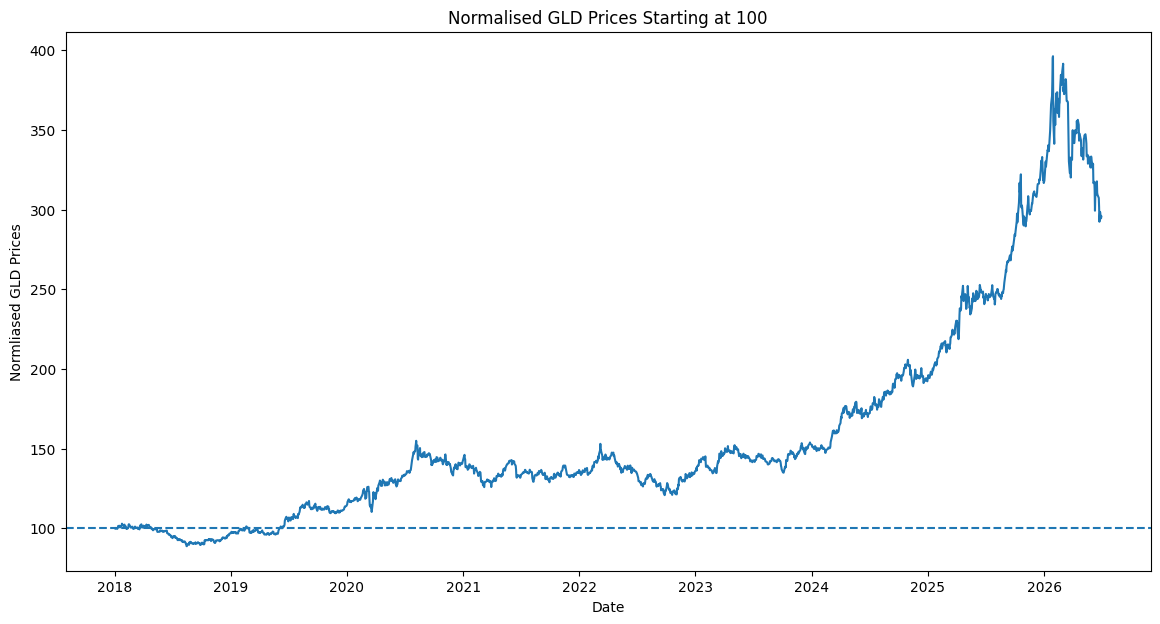

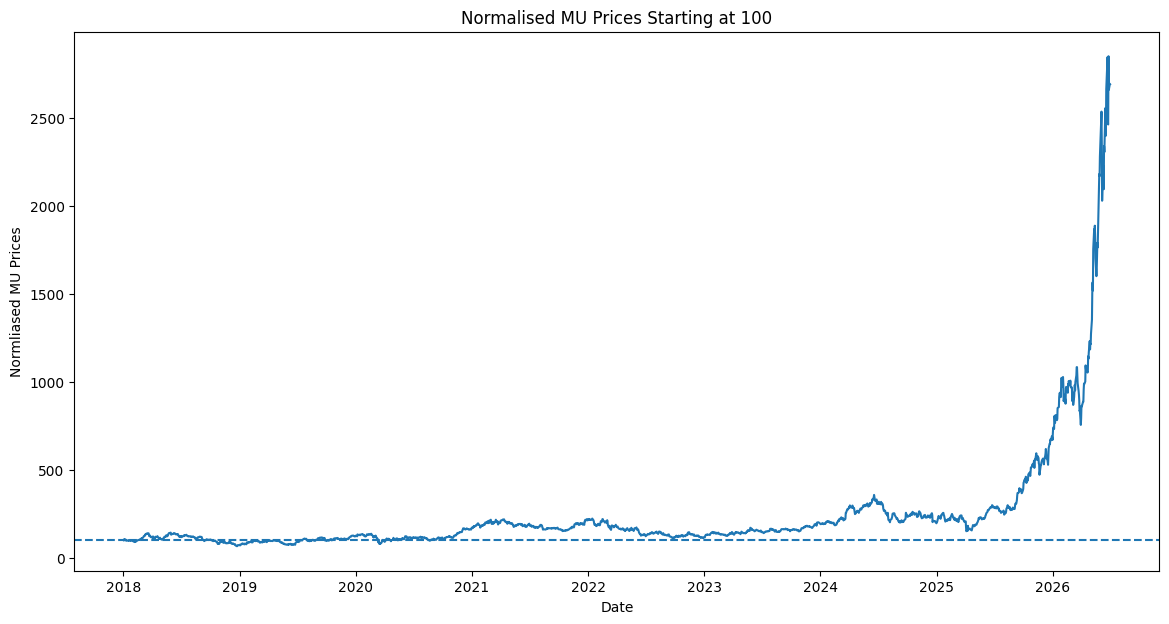

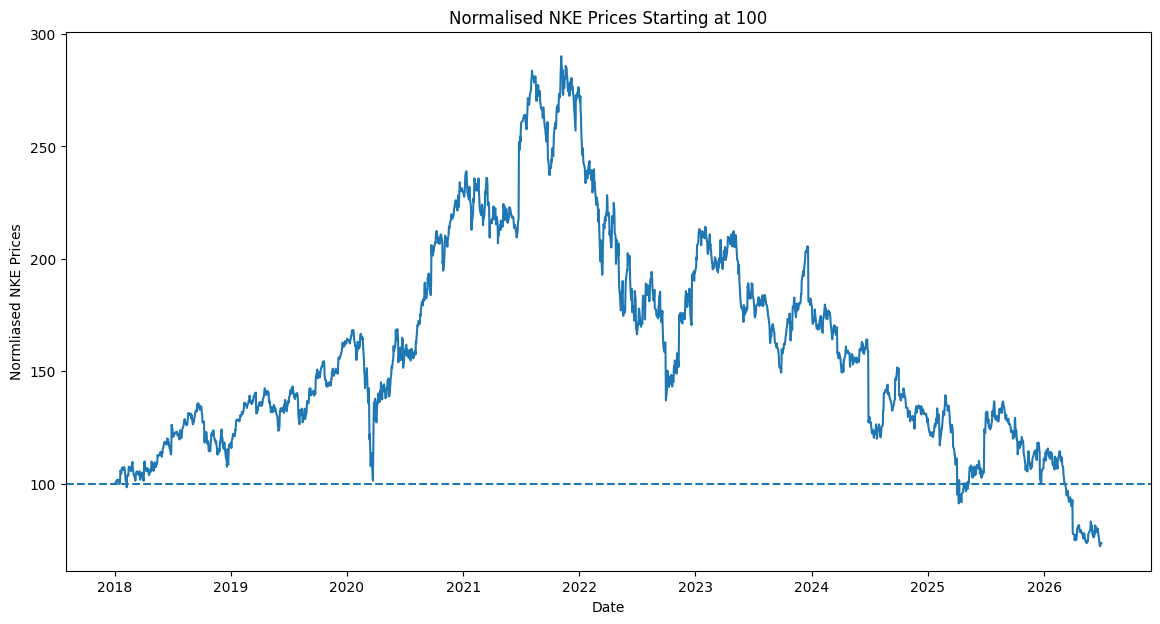

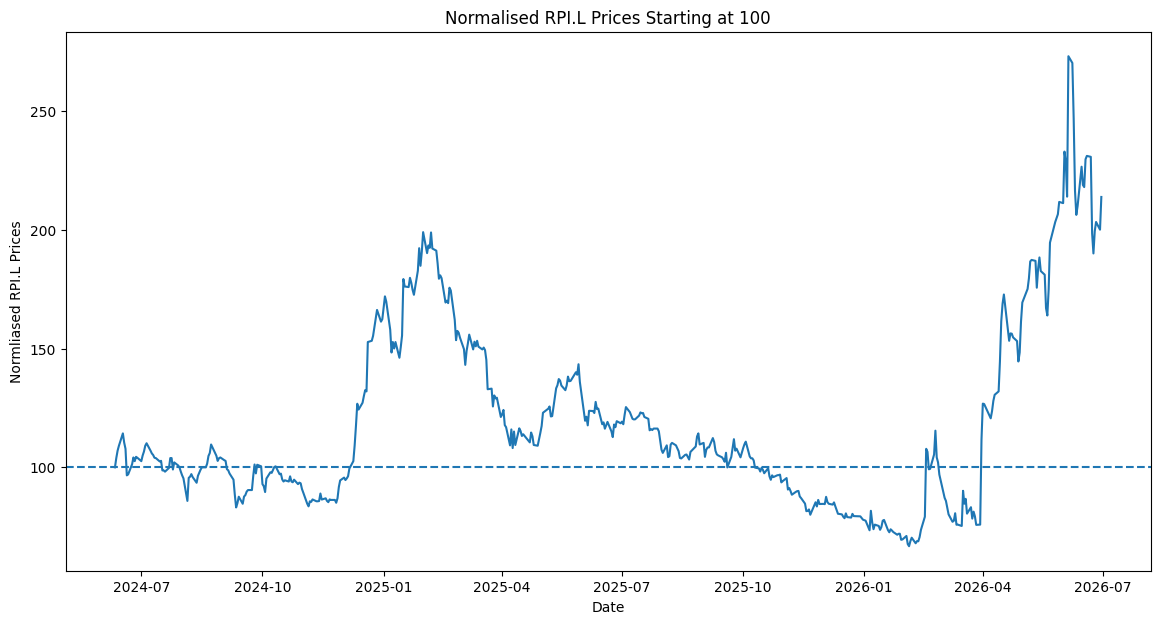

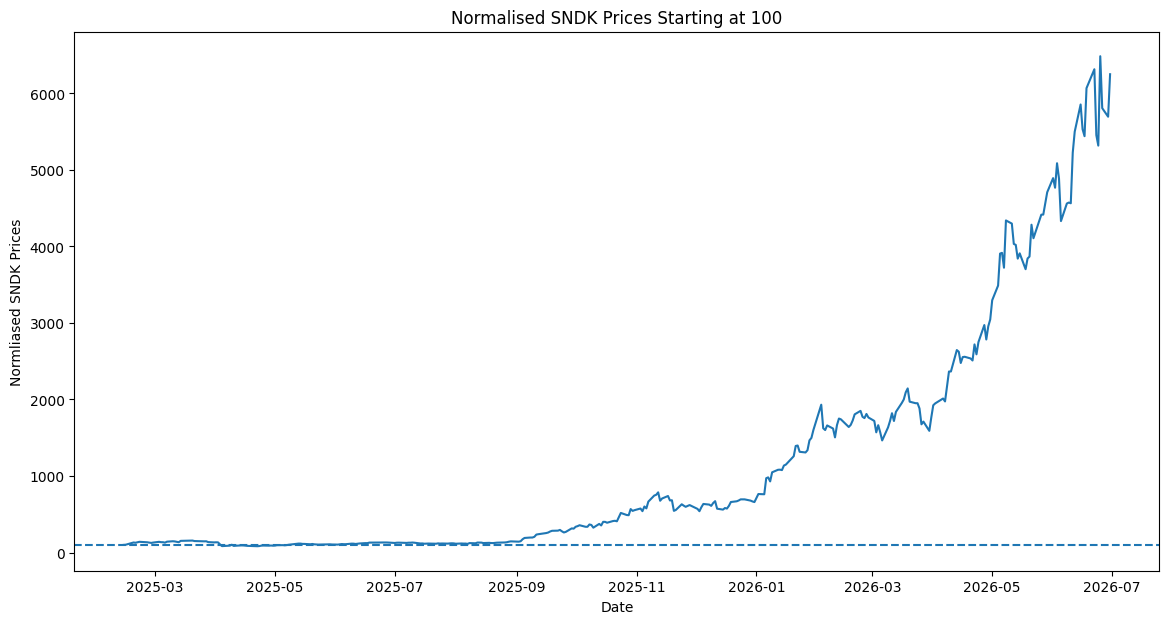

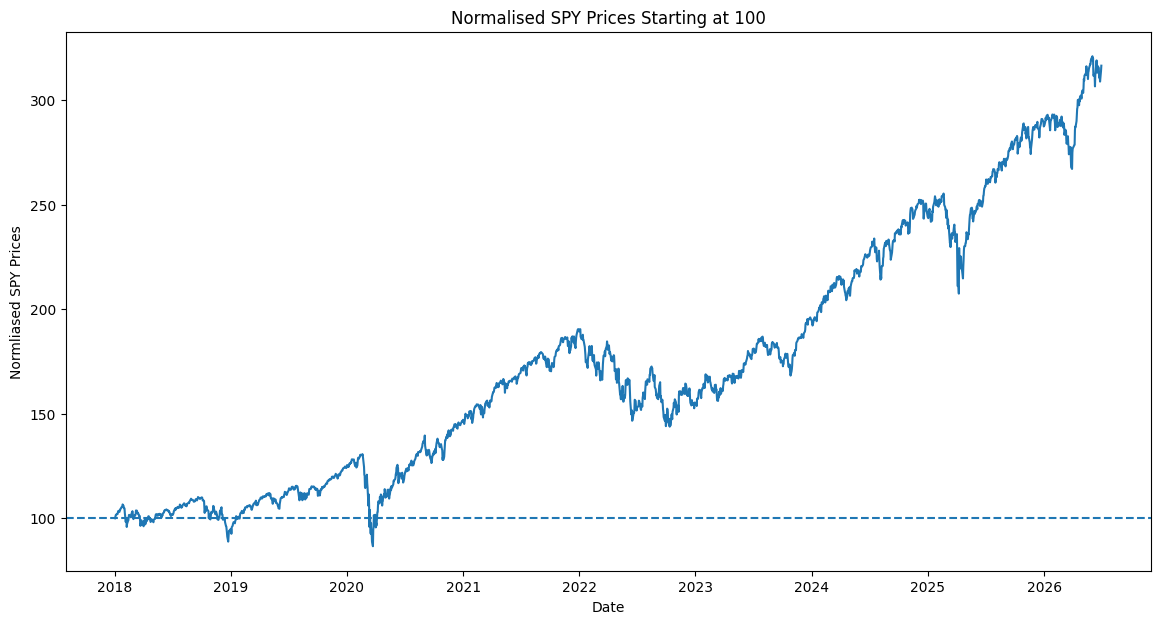

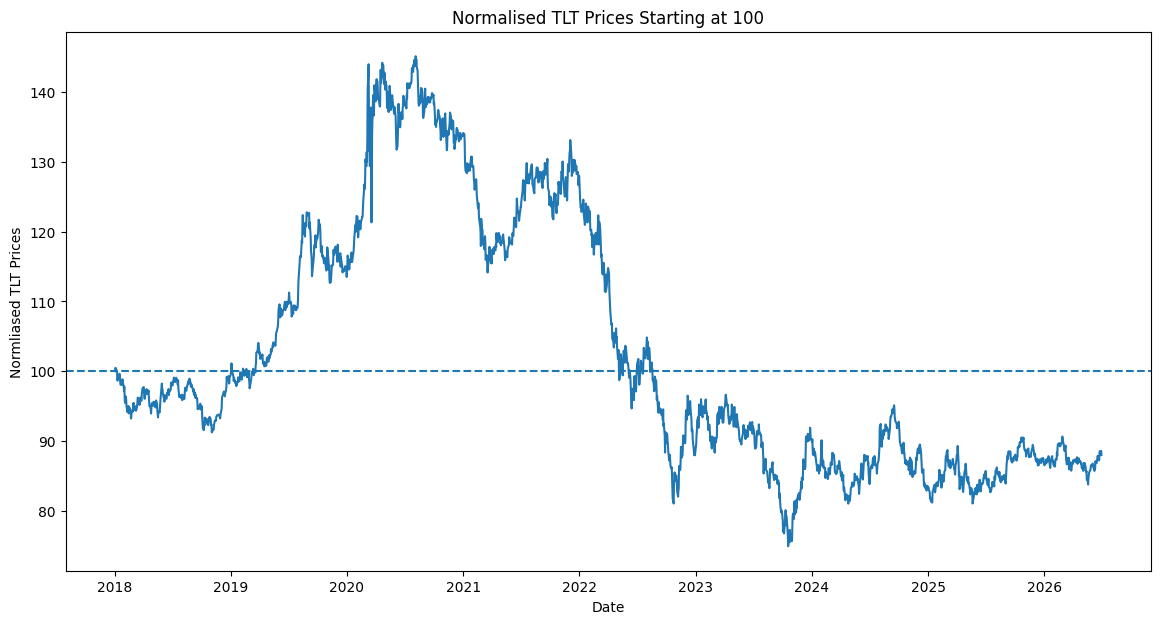

In [18]:
# Compare normalized prices starting at 100:

import matplotlib.pyplot as plt

df = pull_calendar_table(
    table_name = "price_features", 
    calendar = CALENDAR
    )
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["ticker", "date"])

df["normalised_close"] = df.groupby("ticker")["adj_close"].transform(
    lambda x: x / x.iloc[0] * 100
)

for ticker, group in df.groupby("ticker"):
    plt.figure(figsize=(14, 7))
    plt.plot(group["date"], group["normalised_close"], label = ticker)
    
    # adds horizontal line at y = 100
    plt.axhline(100, linestyle = "--")
    
    plt.title(f"Normalised {ticker} Prices Starting at 100")
    plt.xlabel("Date")
    plt.ylabel(f"Normliased {ticker} Prices")
    plt.show()



Identify major price jumps or drops:

- 3 equity tickers (MU, RPI.L, and SNDK) show huge price jumps round the start of 2026. 
- MU relatively stable price until mid 2025 where rapid growth sees stock 25x in under a year.
- SNDK in particular has shown a massive price jump going to 60x normalised price since it began trading.
- RPI.L had a large price jump at start of 2025 and 2026.

- the remaining tickers in comparison show relatively lower price movements.
- GLD showed relatively steep rise 2024-2026 compared to 2018-2025. Sharp drop in 2026-present.
- NKE in comparison shows minimal jumps but in relativity had steep drop in 2020 which led into steep build up then steep drop after 2022.
- TLT show relatively steep drops in cyclical periods through years.

Check whether any ticker behaves unusually:
- 3 equity stocks chosen experienced huge growth recently due to infrastructure demand for AI. There recent popularity in the news was the reason they were chosen.
- NKE has had negative growth since 2022.


## 4. Return analysis
- [ ] Plot daily returns over time
- [ ] Plot return distributions
- [ ] Compare average daily returns by ticker
- [ ] Compare return volatility by ticker
- [ ] Identify extreme return days
- [ ] Check skewness/kurtosis if you want extra depth
- [ ] Write 2–3 observations


In [19]:
print(df.columns)

Index(['ticker', 'date', 'open', 'high', 'low', 'close', 'adj_close', 'volume',
       'daily_return_no_calendar', 'log_return_no_calendar',
       'cumulative_returns_no_calendar', 'rolling_7d_return_no_calendar',
       'rolling_30d_return_no_calendar', 'lag_1_return_no_calendar',
       'lag_5_return_no_calendar', 'moving_avg_20_no_calendar',
       'moving_avg_50_no_calendar', 'price_vs_ma20_no_calendar',
       'relative_volume_no_calendar', 'rolling_30d_volatility_no_calendar',
       'drawdown_no_calendar', 'target_next_day_return_no_calendar',
       'target_direction_no_calendar', 'normalised_close'],
      dtype='str')


[START] Connecting to database...
[START] Reading price_features
[DONE] Read price_features
[START] Building no_calendar required columns...
[DONE] Filtered to no_calendar


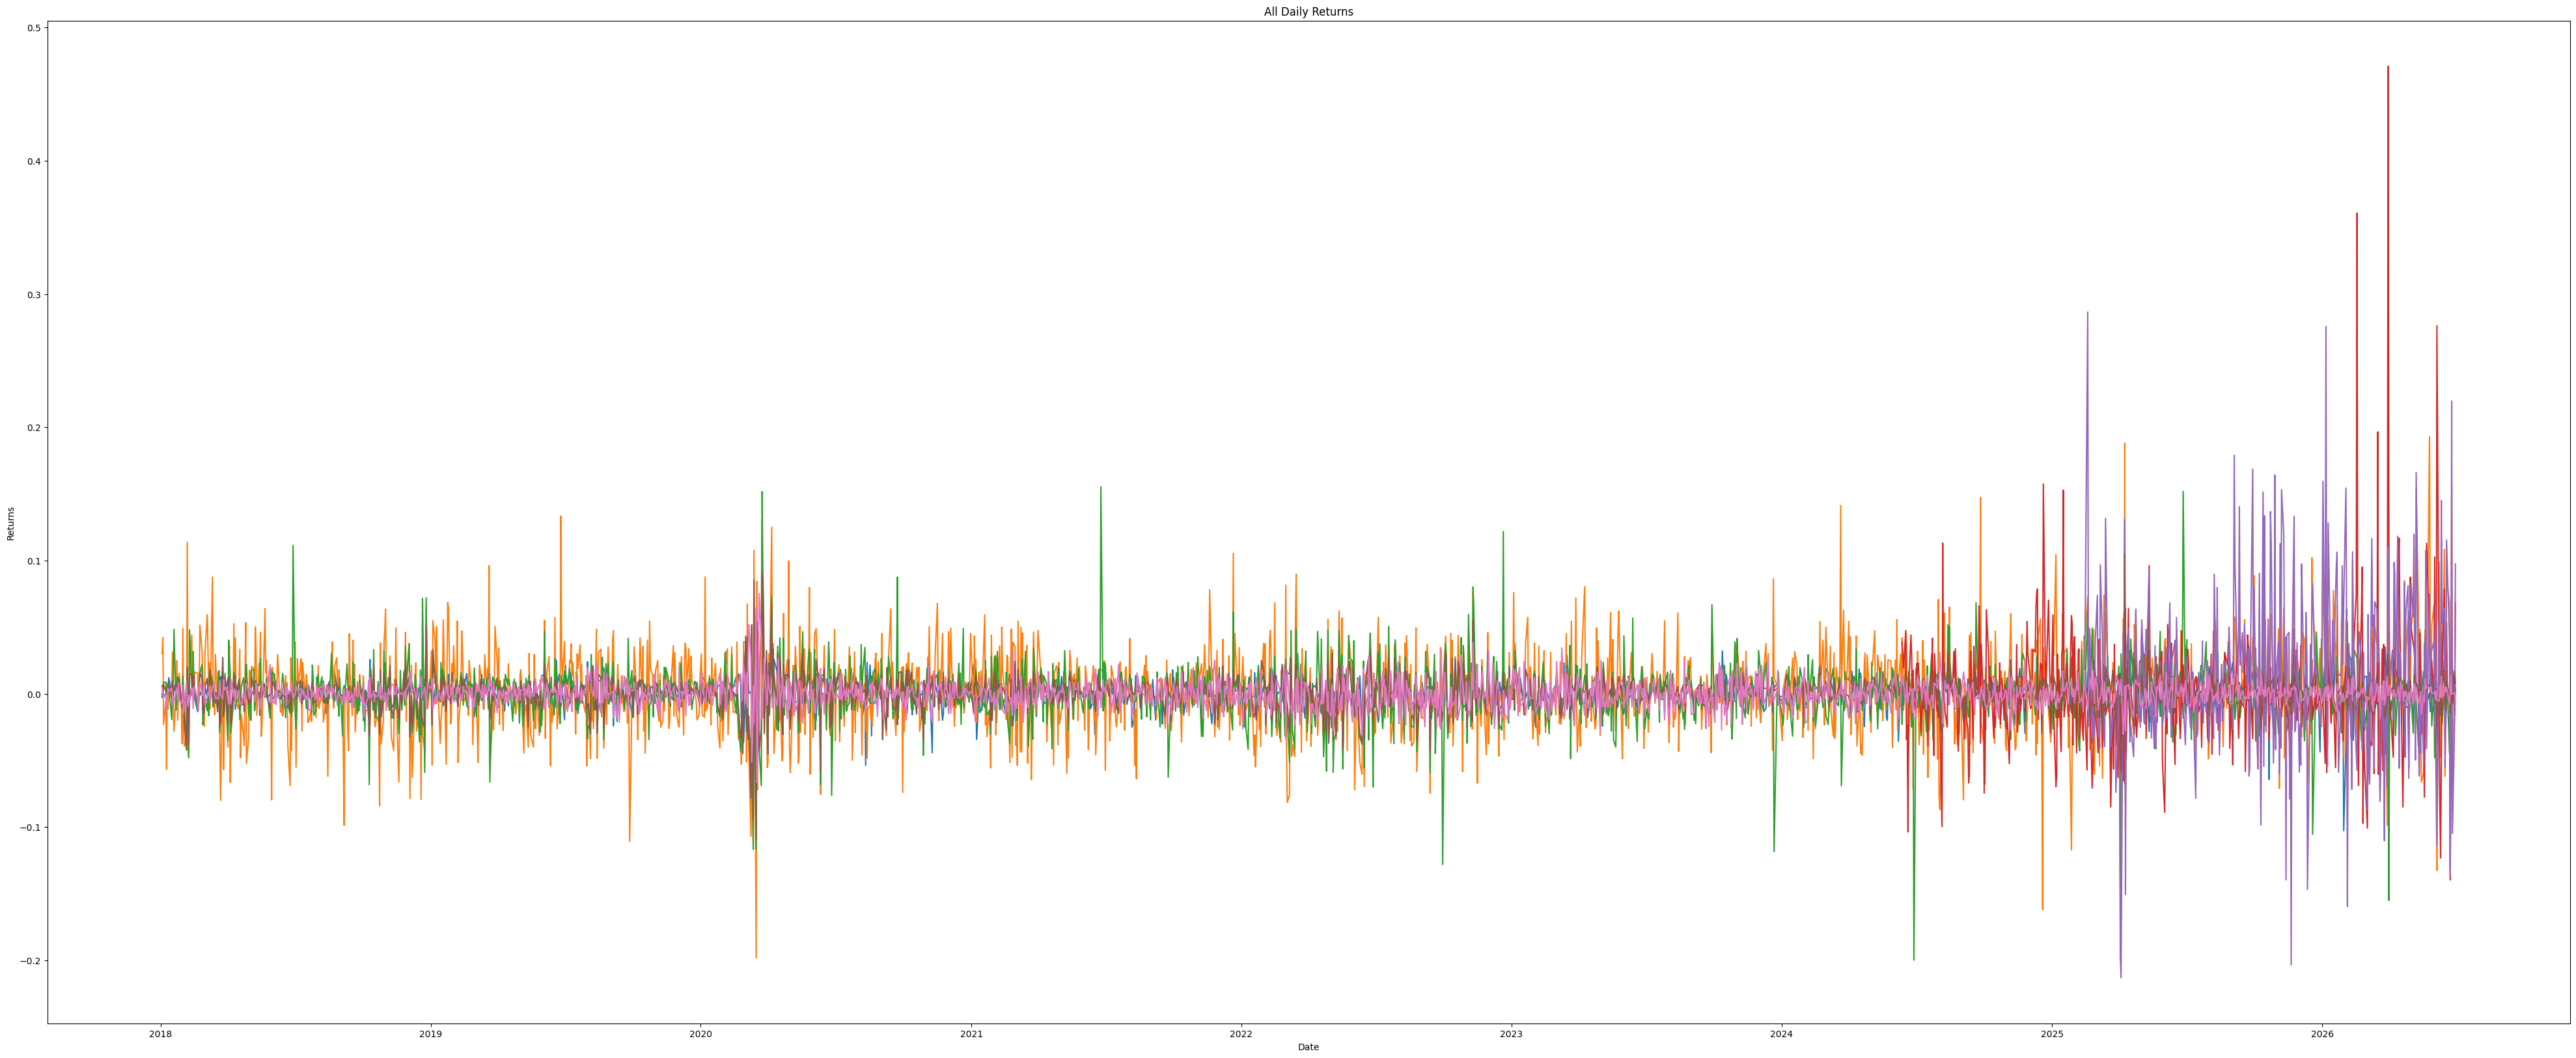

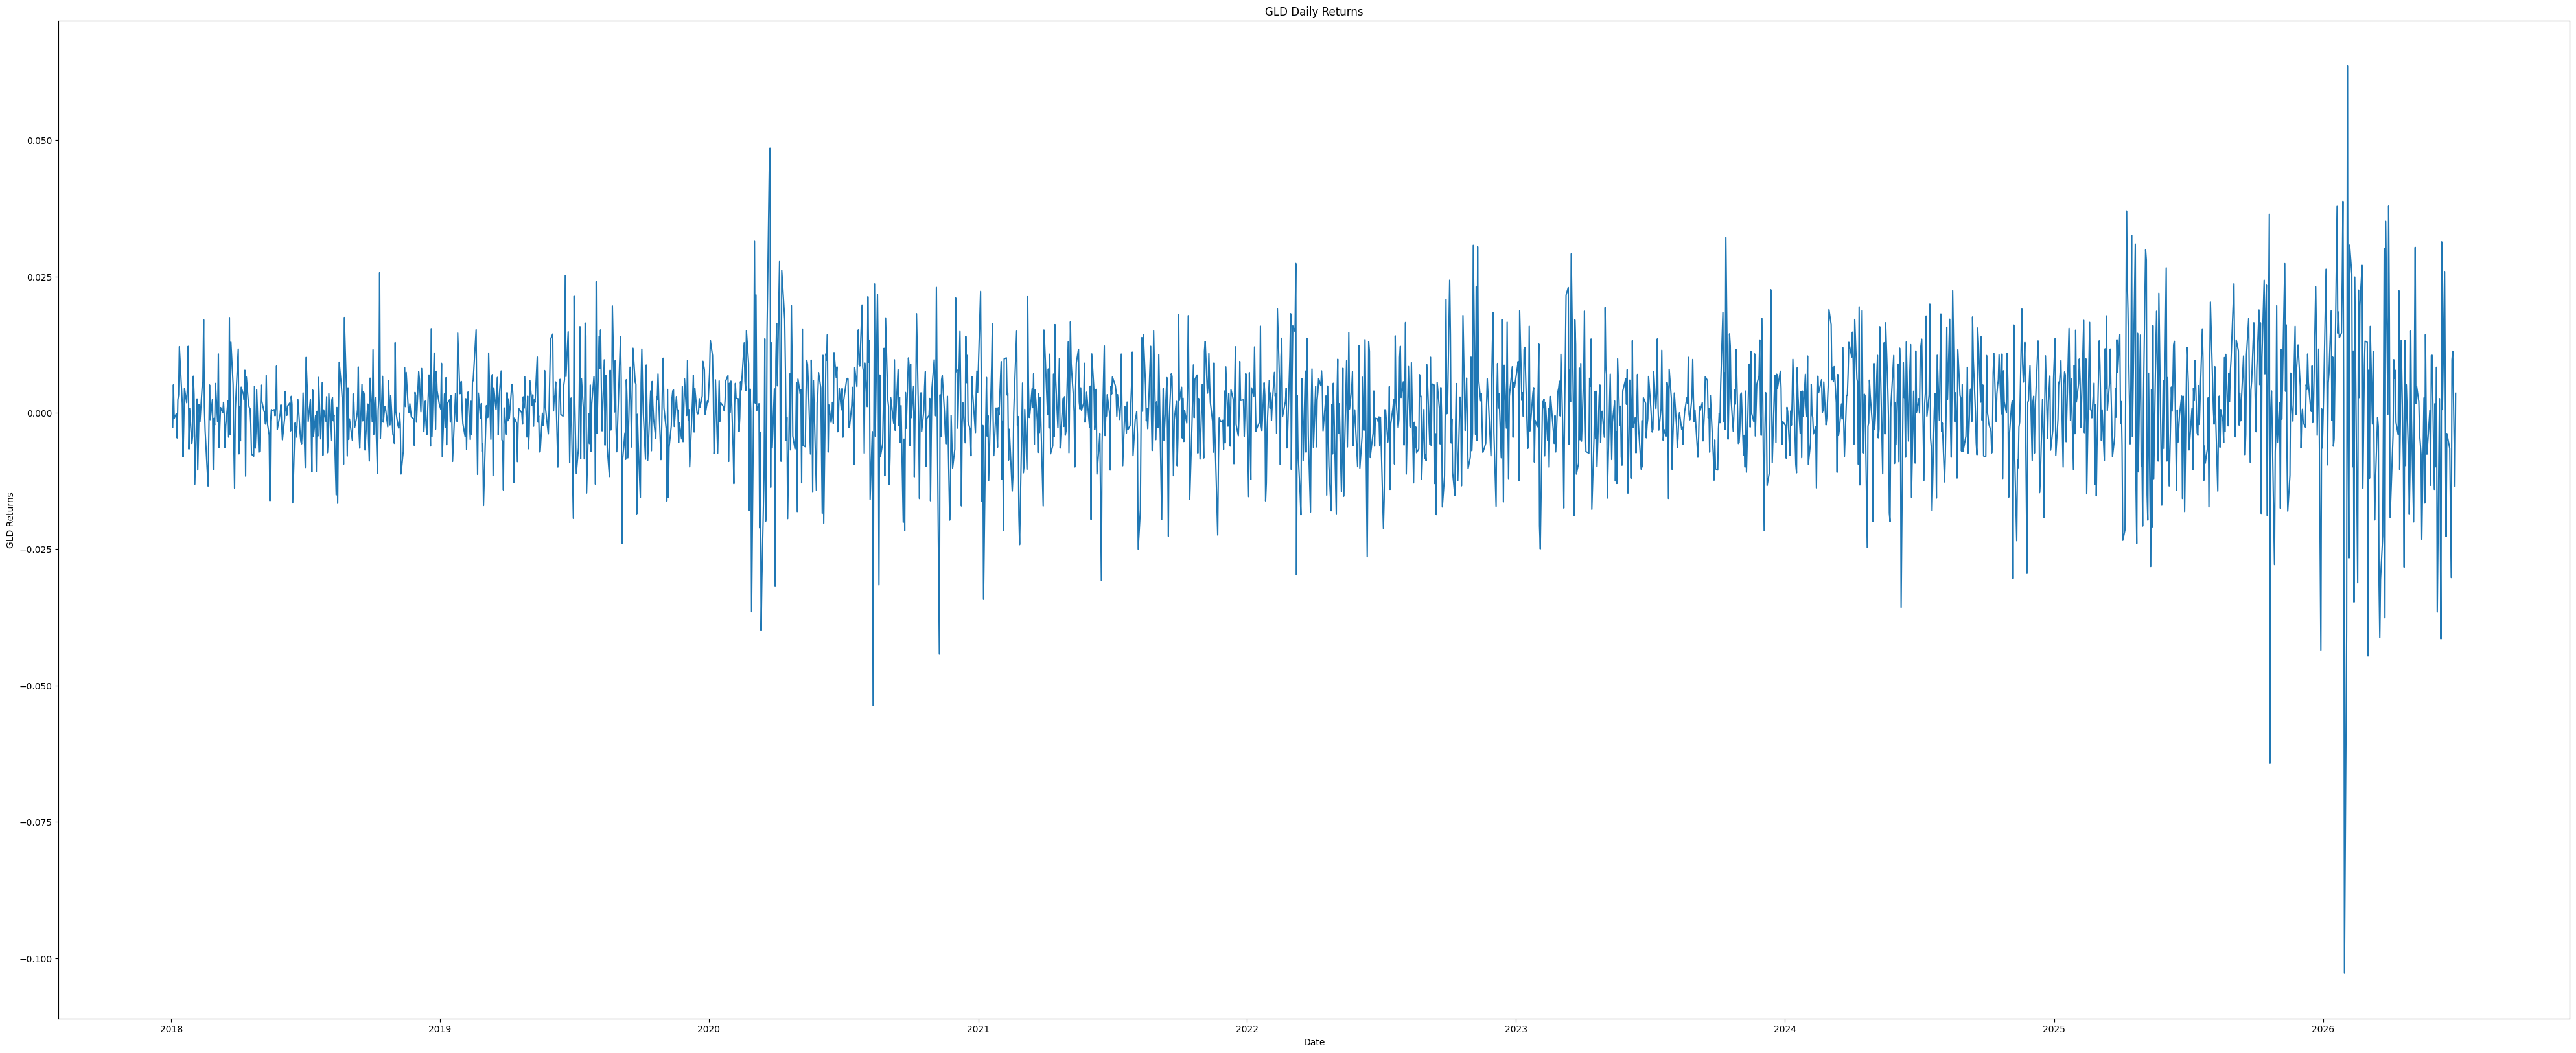

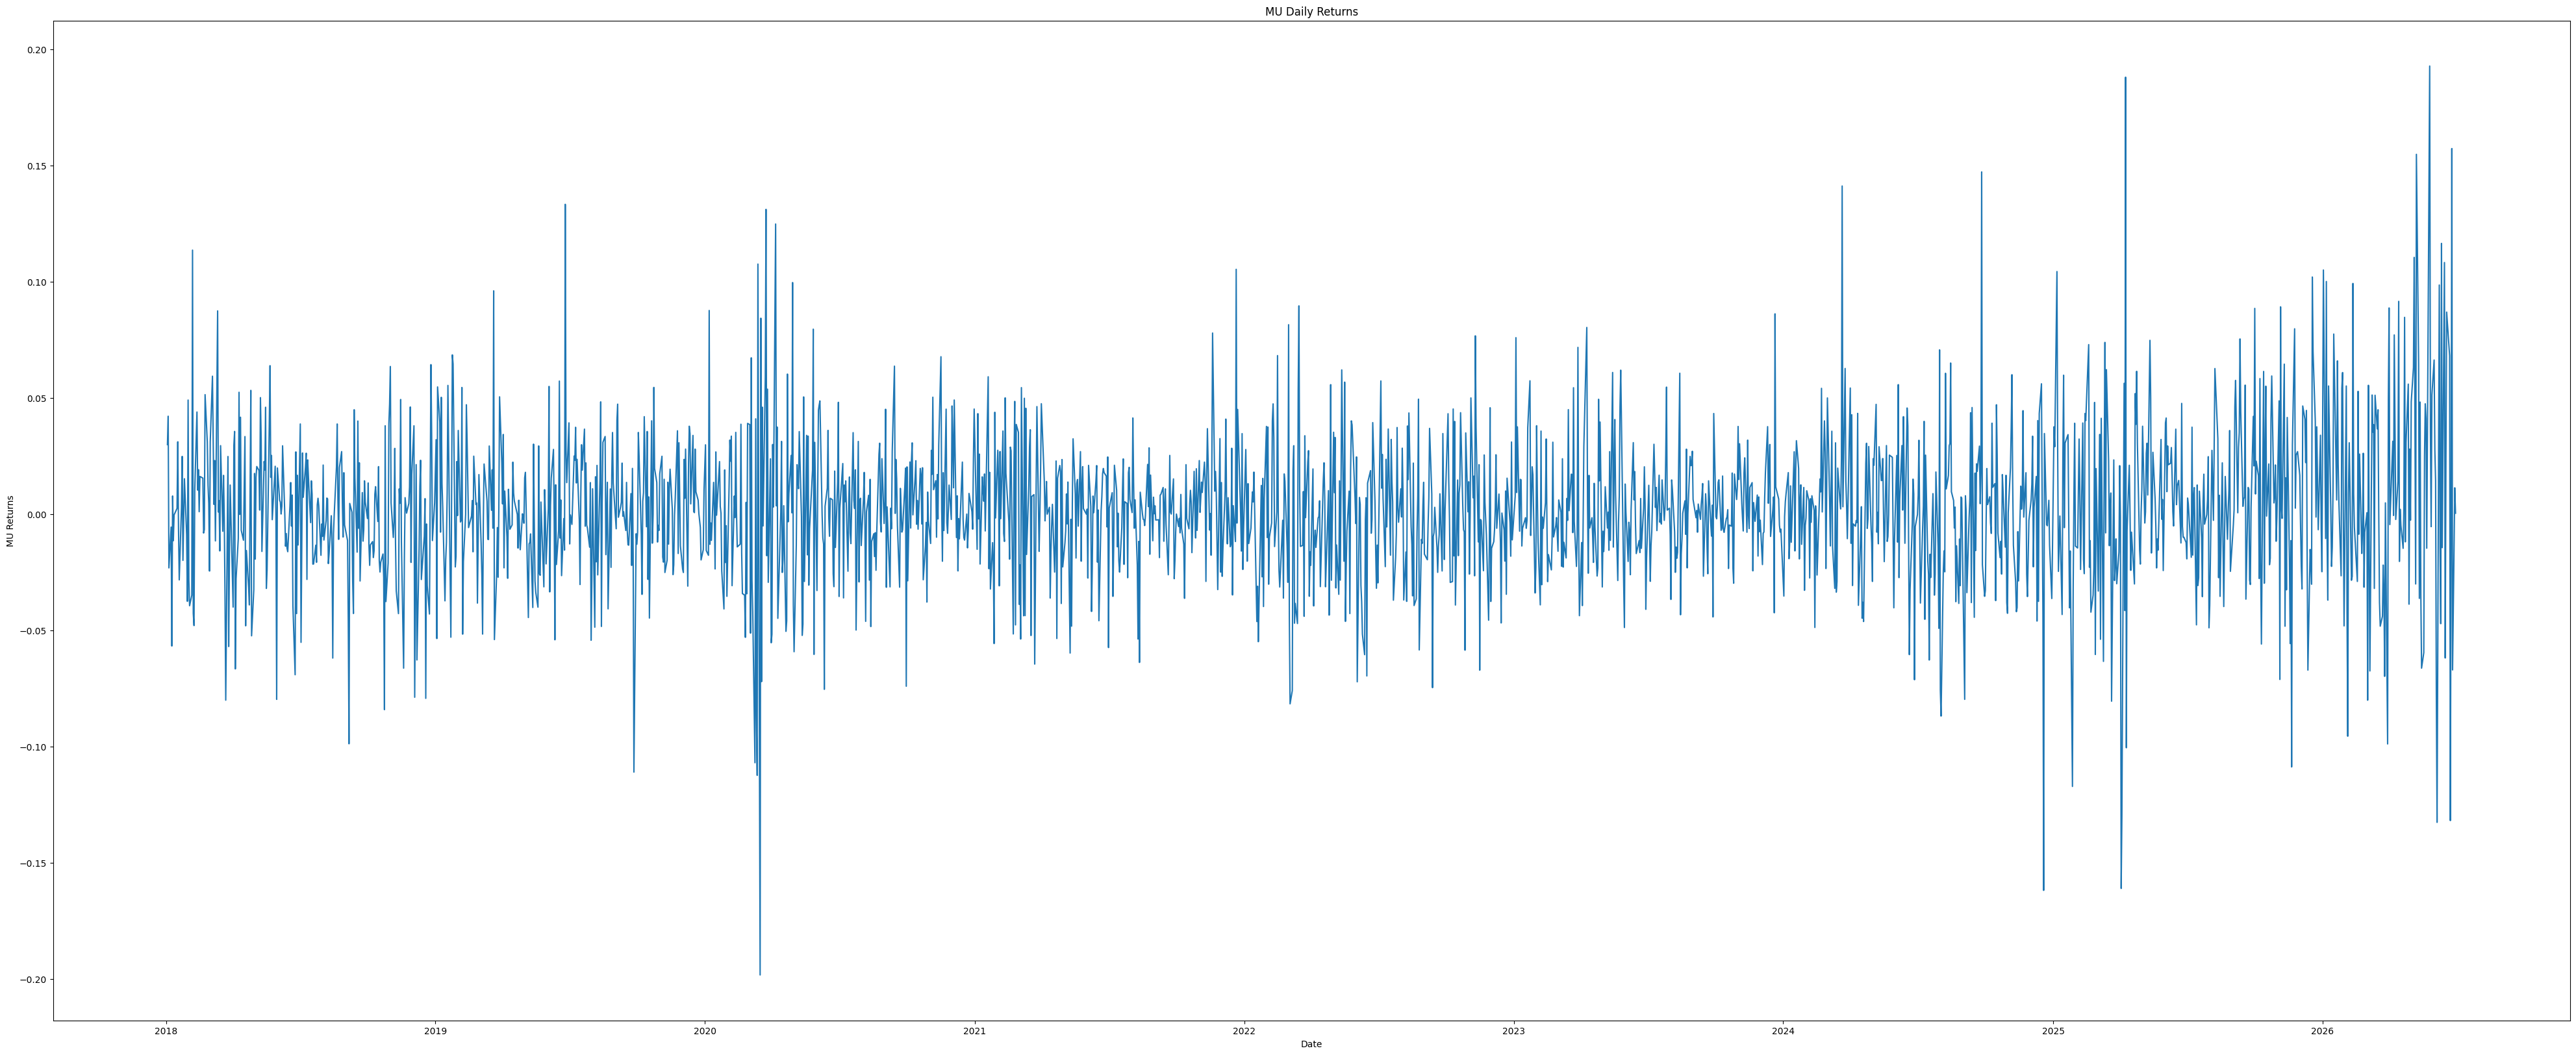

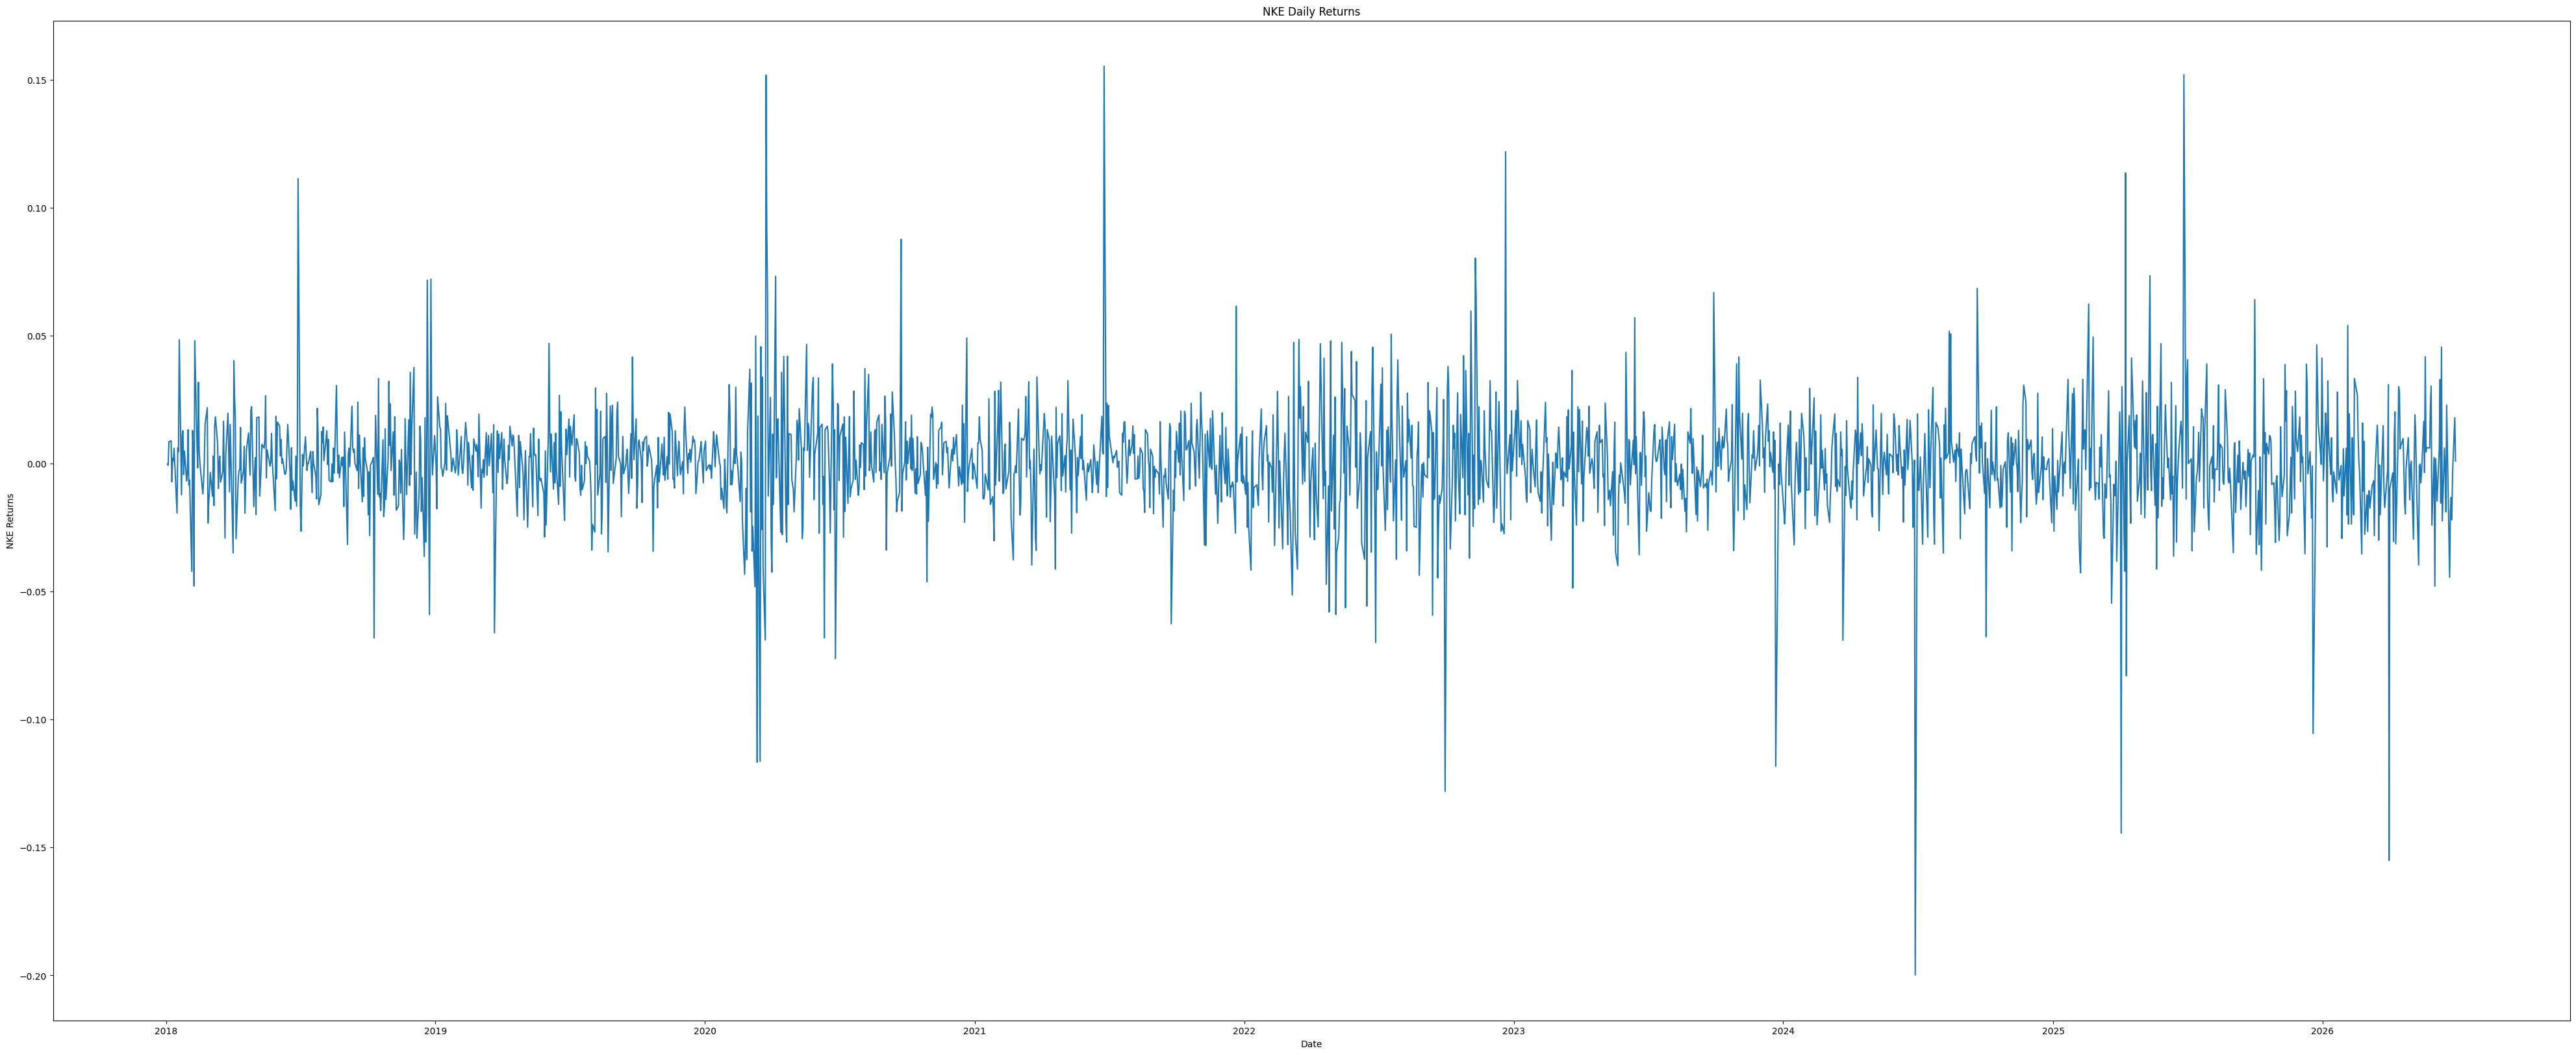

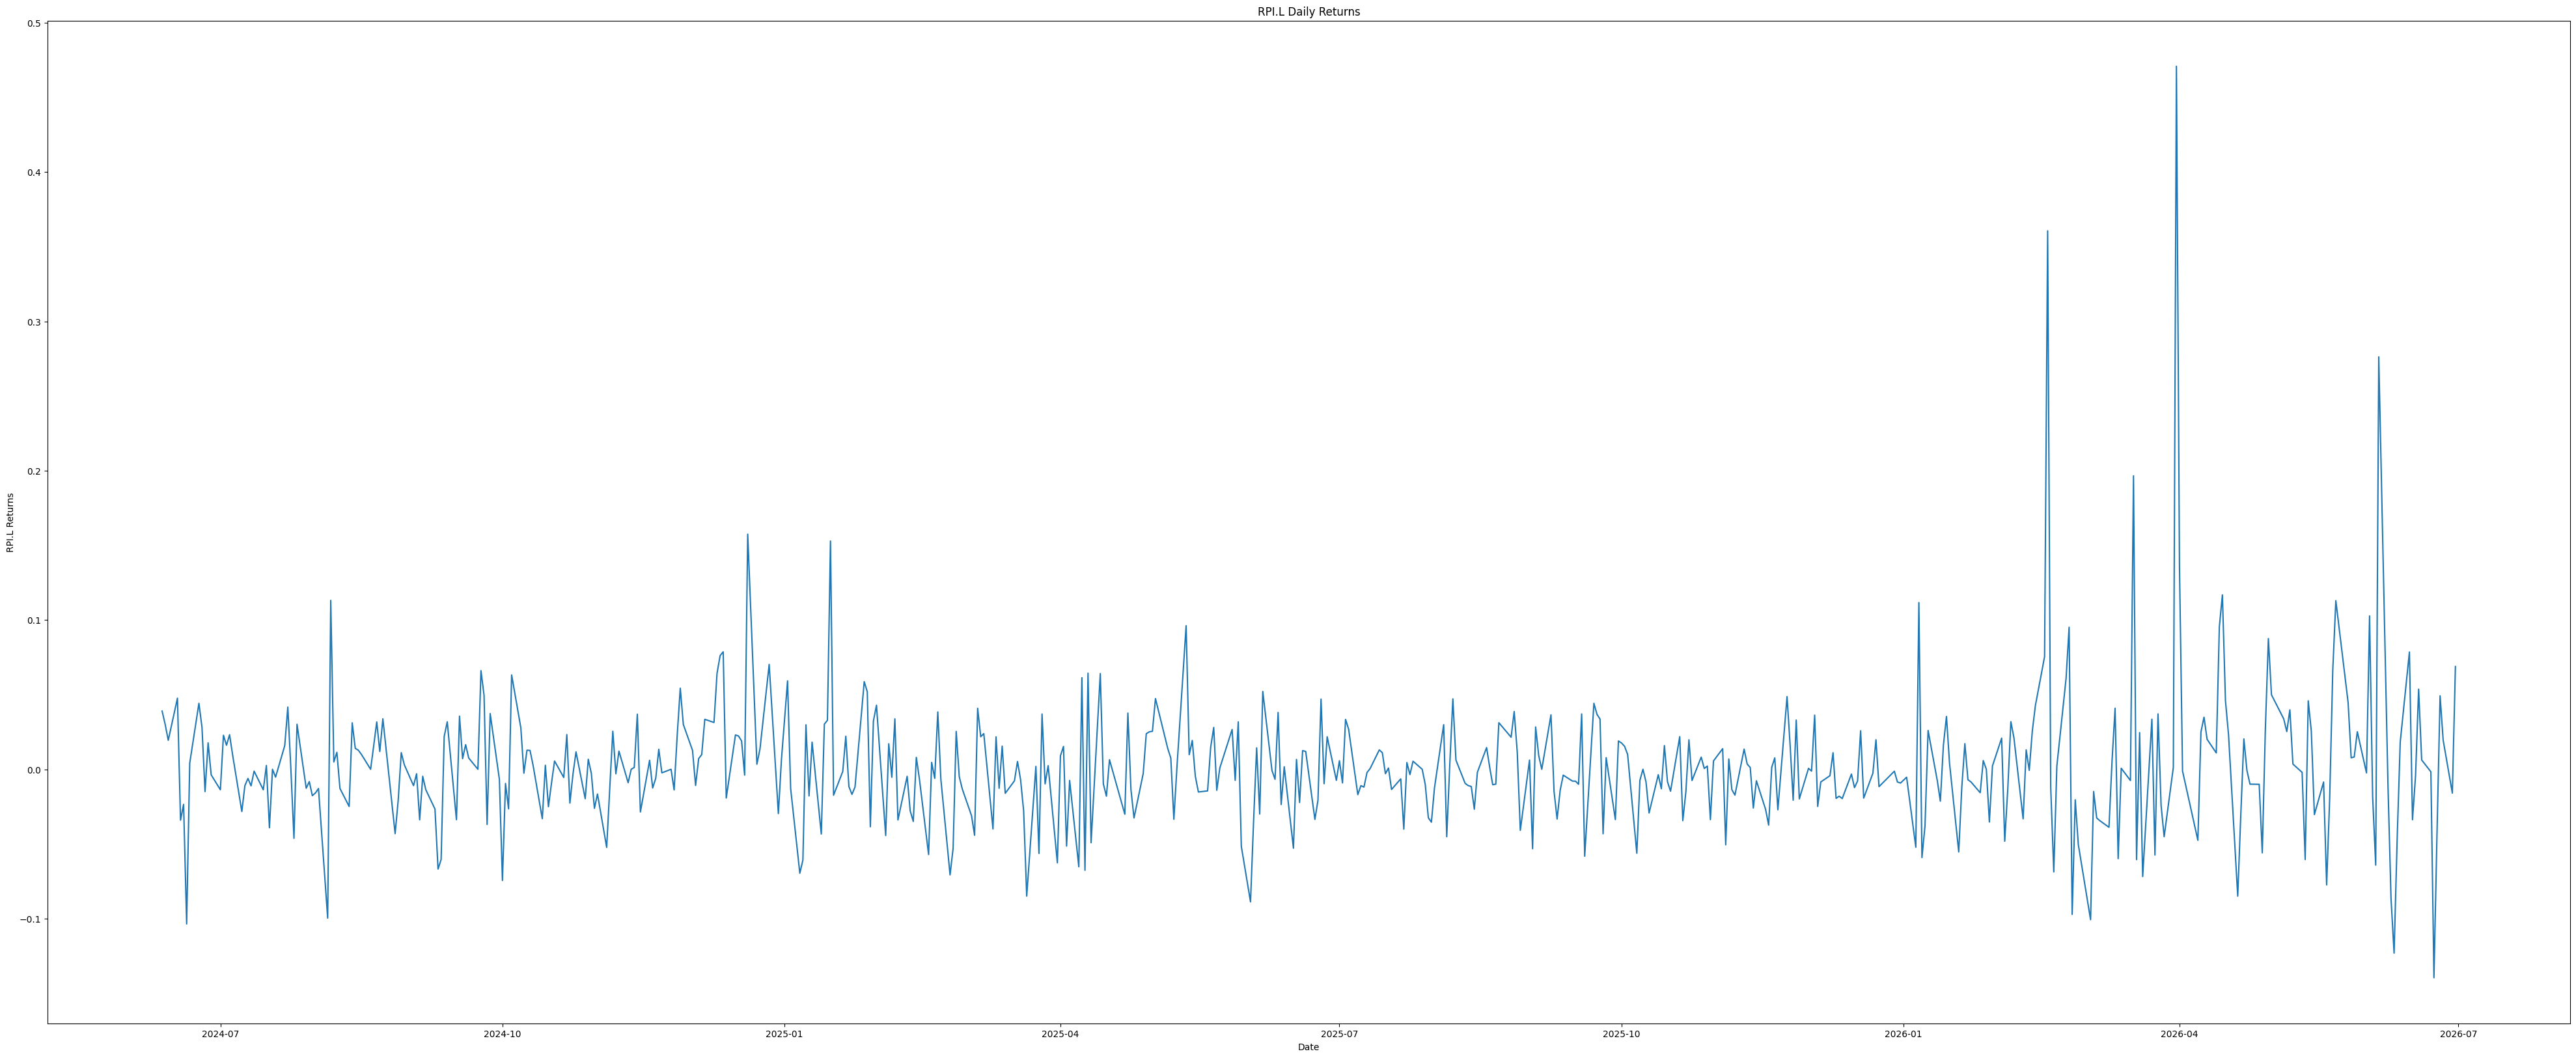

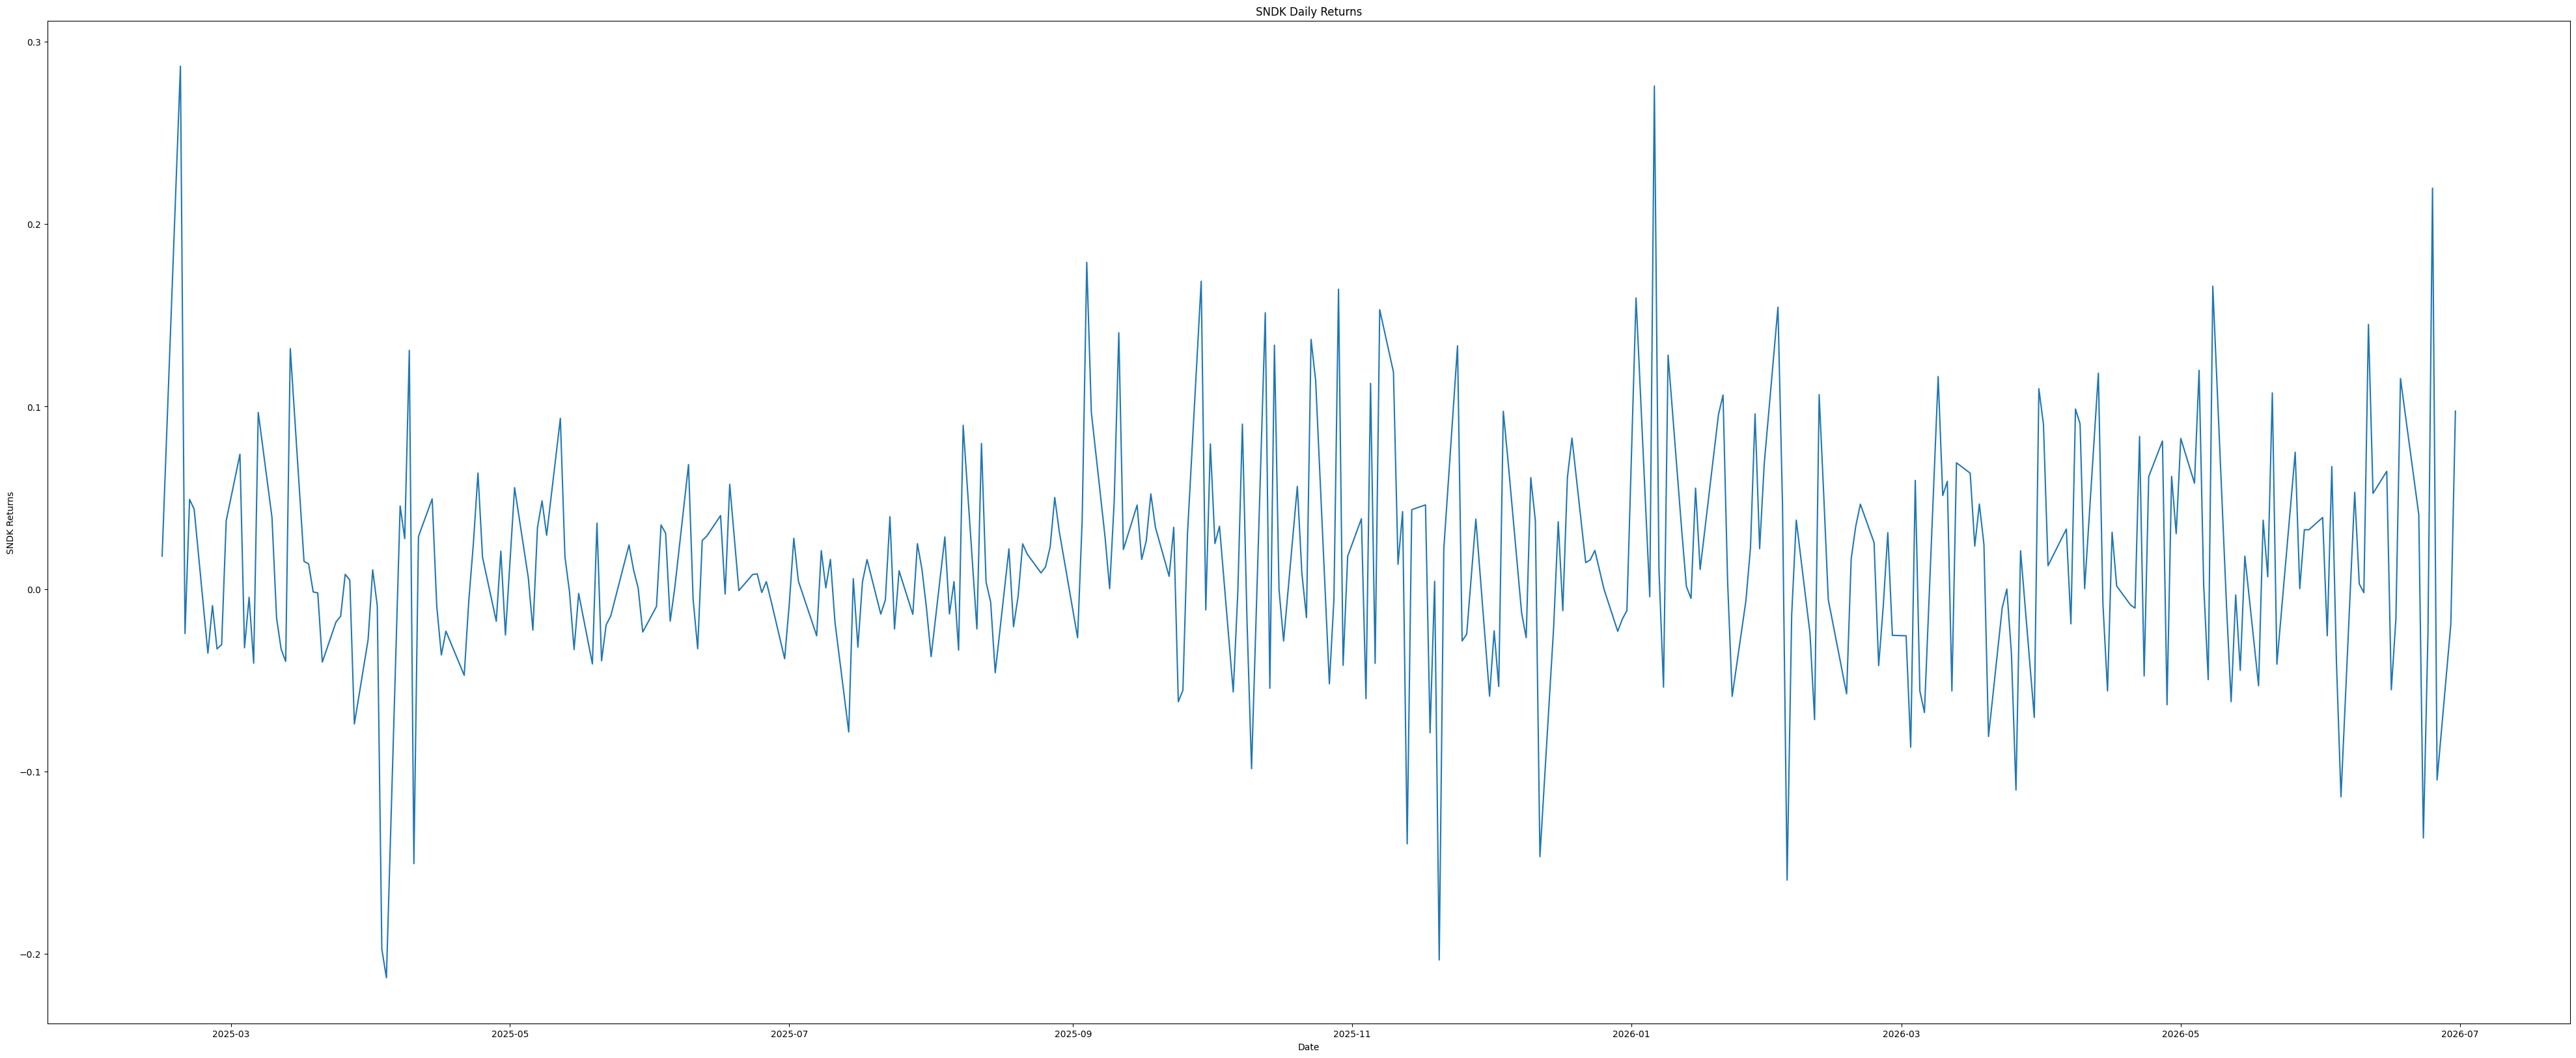

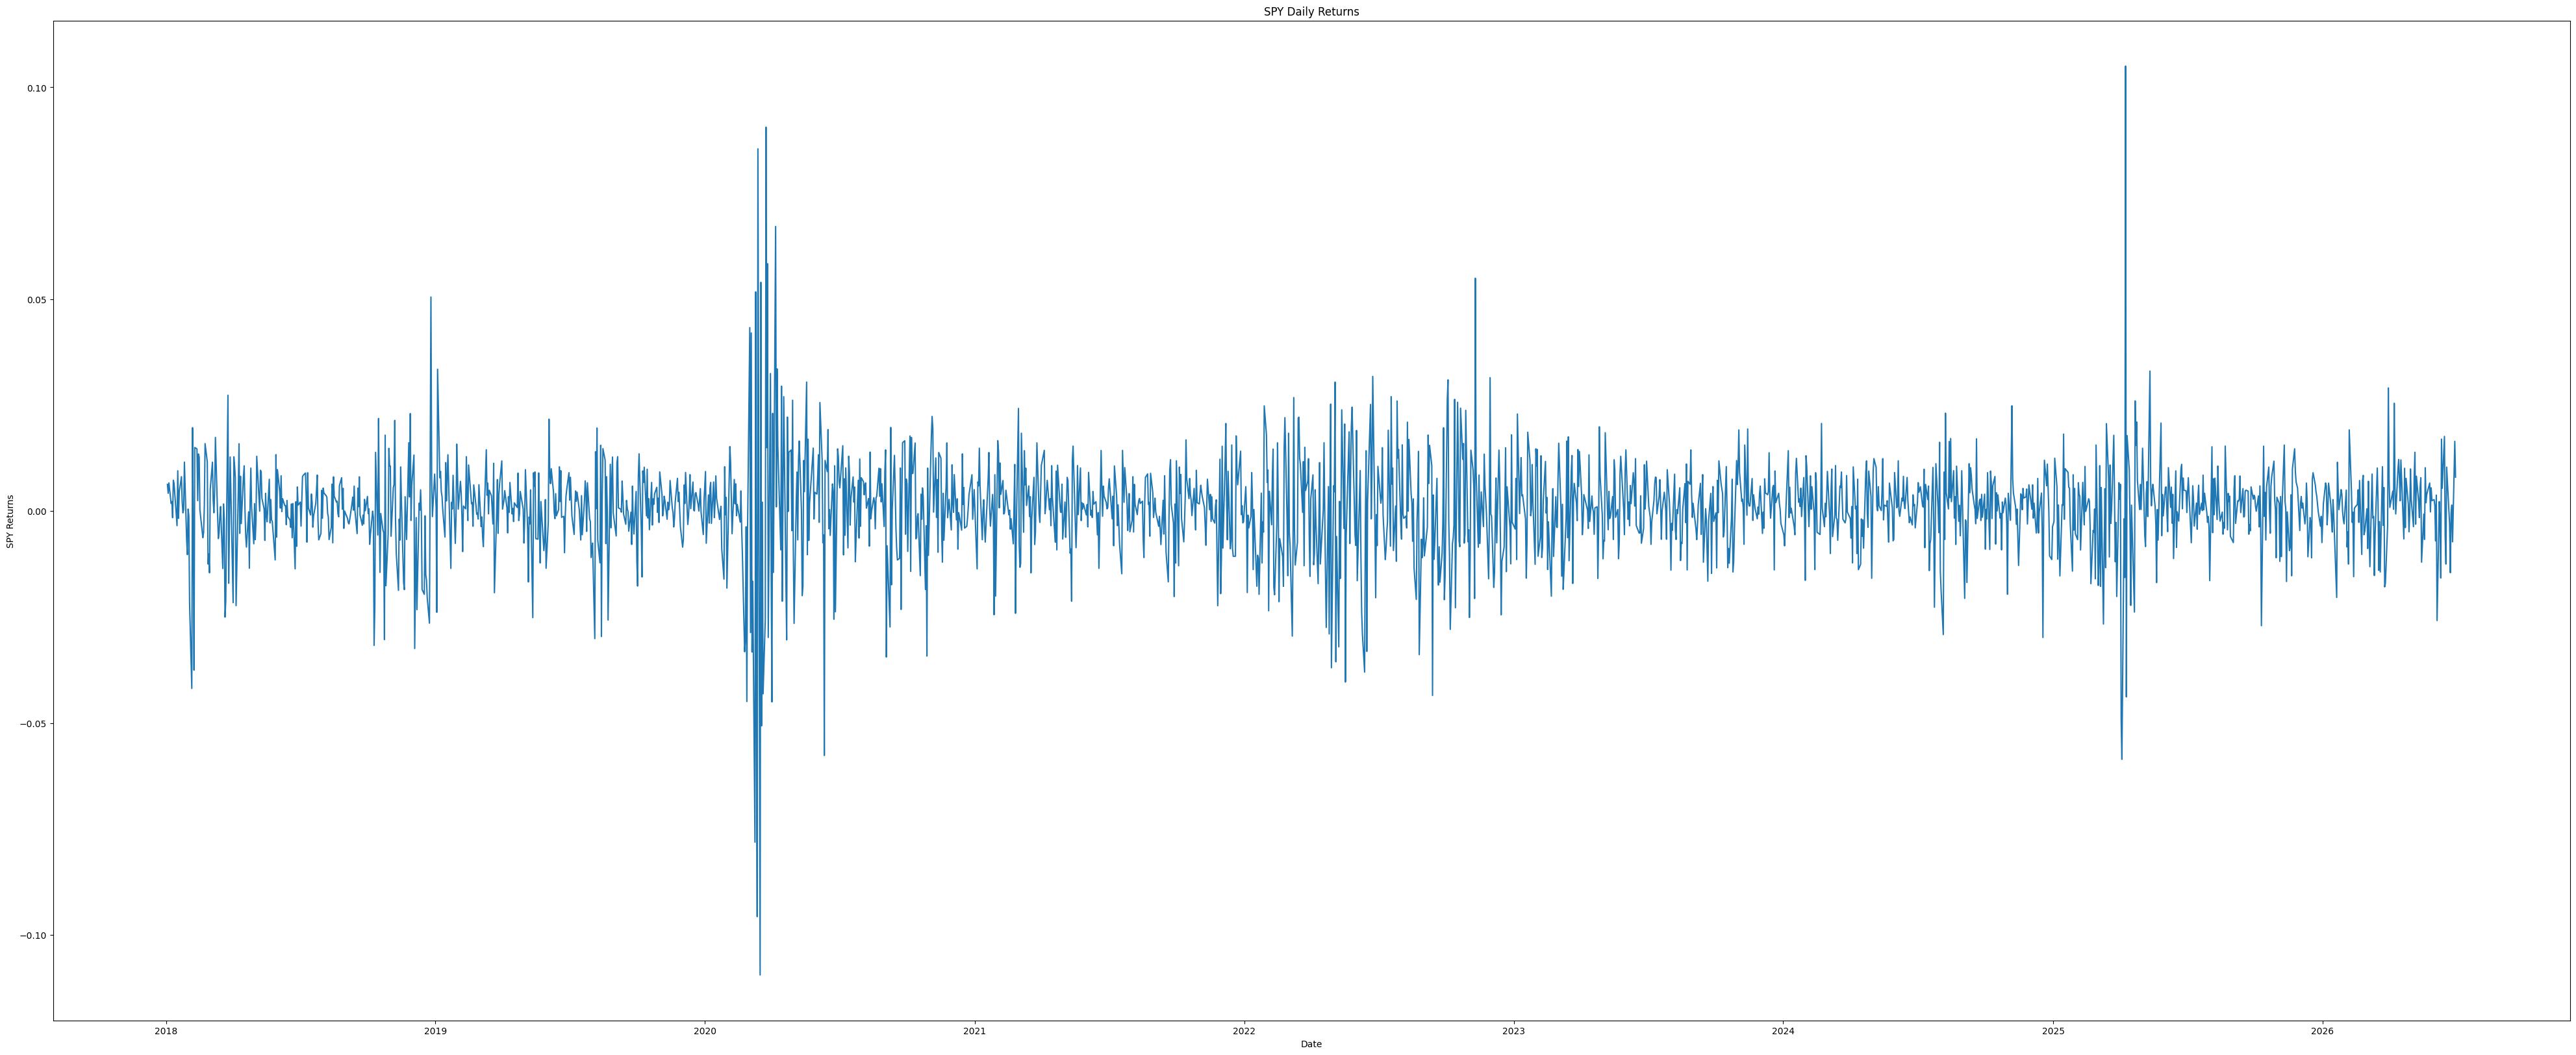

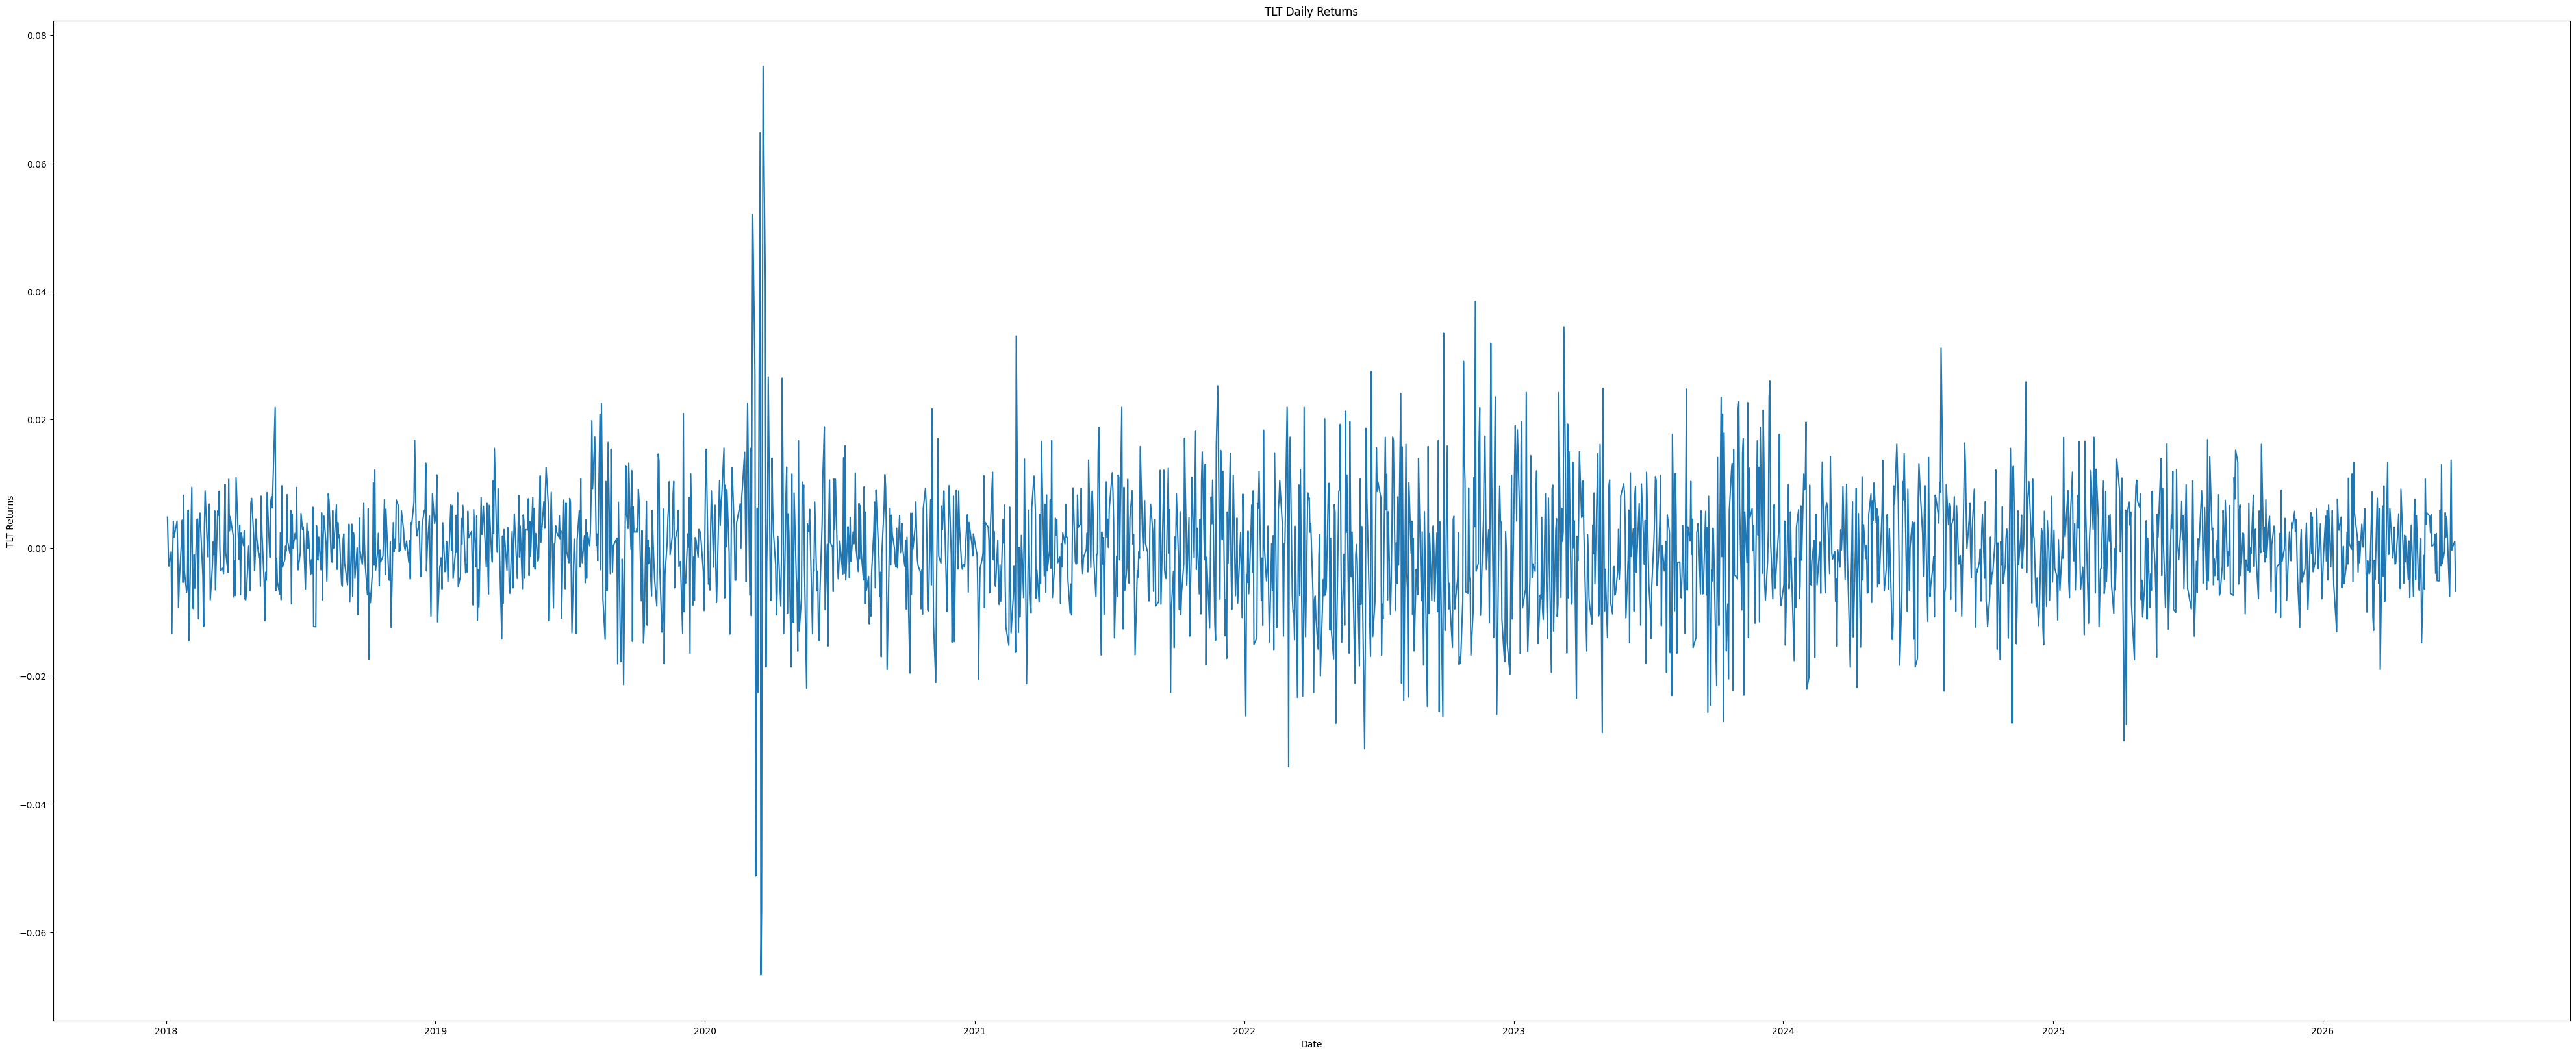

In [20]:
# Plot daily returns over time

import matplotlib.pyplot as plt

df = pull_calendar_table(
    table_name = "price_features",
    calendar = CALENDAR
)

daily_return = f"daily_return_{CALENDAR}"

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["ticker", "date"])

plt.figure(figsize=(50,20))

for ticker, group in df.groupby("ticker"):
    plt.plot(group["date"], group[daily_return], label = ticker)

plt.title("All Daily Returns")
plt.xlabel("Date")
plt.ylabel("Returns")
plt.show()

for ticker, group in df.groupby("ticker"):
    plt.figure(figsize=(50,20))
    plt.plot(group["date"], group[daily_return], label = ticker)
    plt.title(f"{ticker} Daily Returns")
    plt.xlabel("Date")
    plt.ylabel(f"{ticker} Returns")
    plt.show()

[START] Connecting to database...
[START] Reading price_features
[DONE] Read price_features
[START] Building no_calendar required columns...
[DONE] Filtered to no_calendar


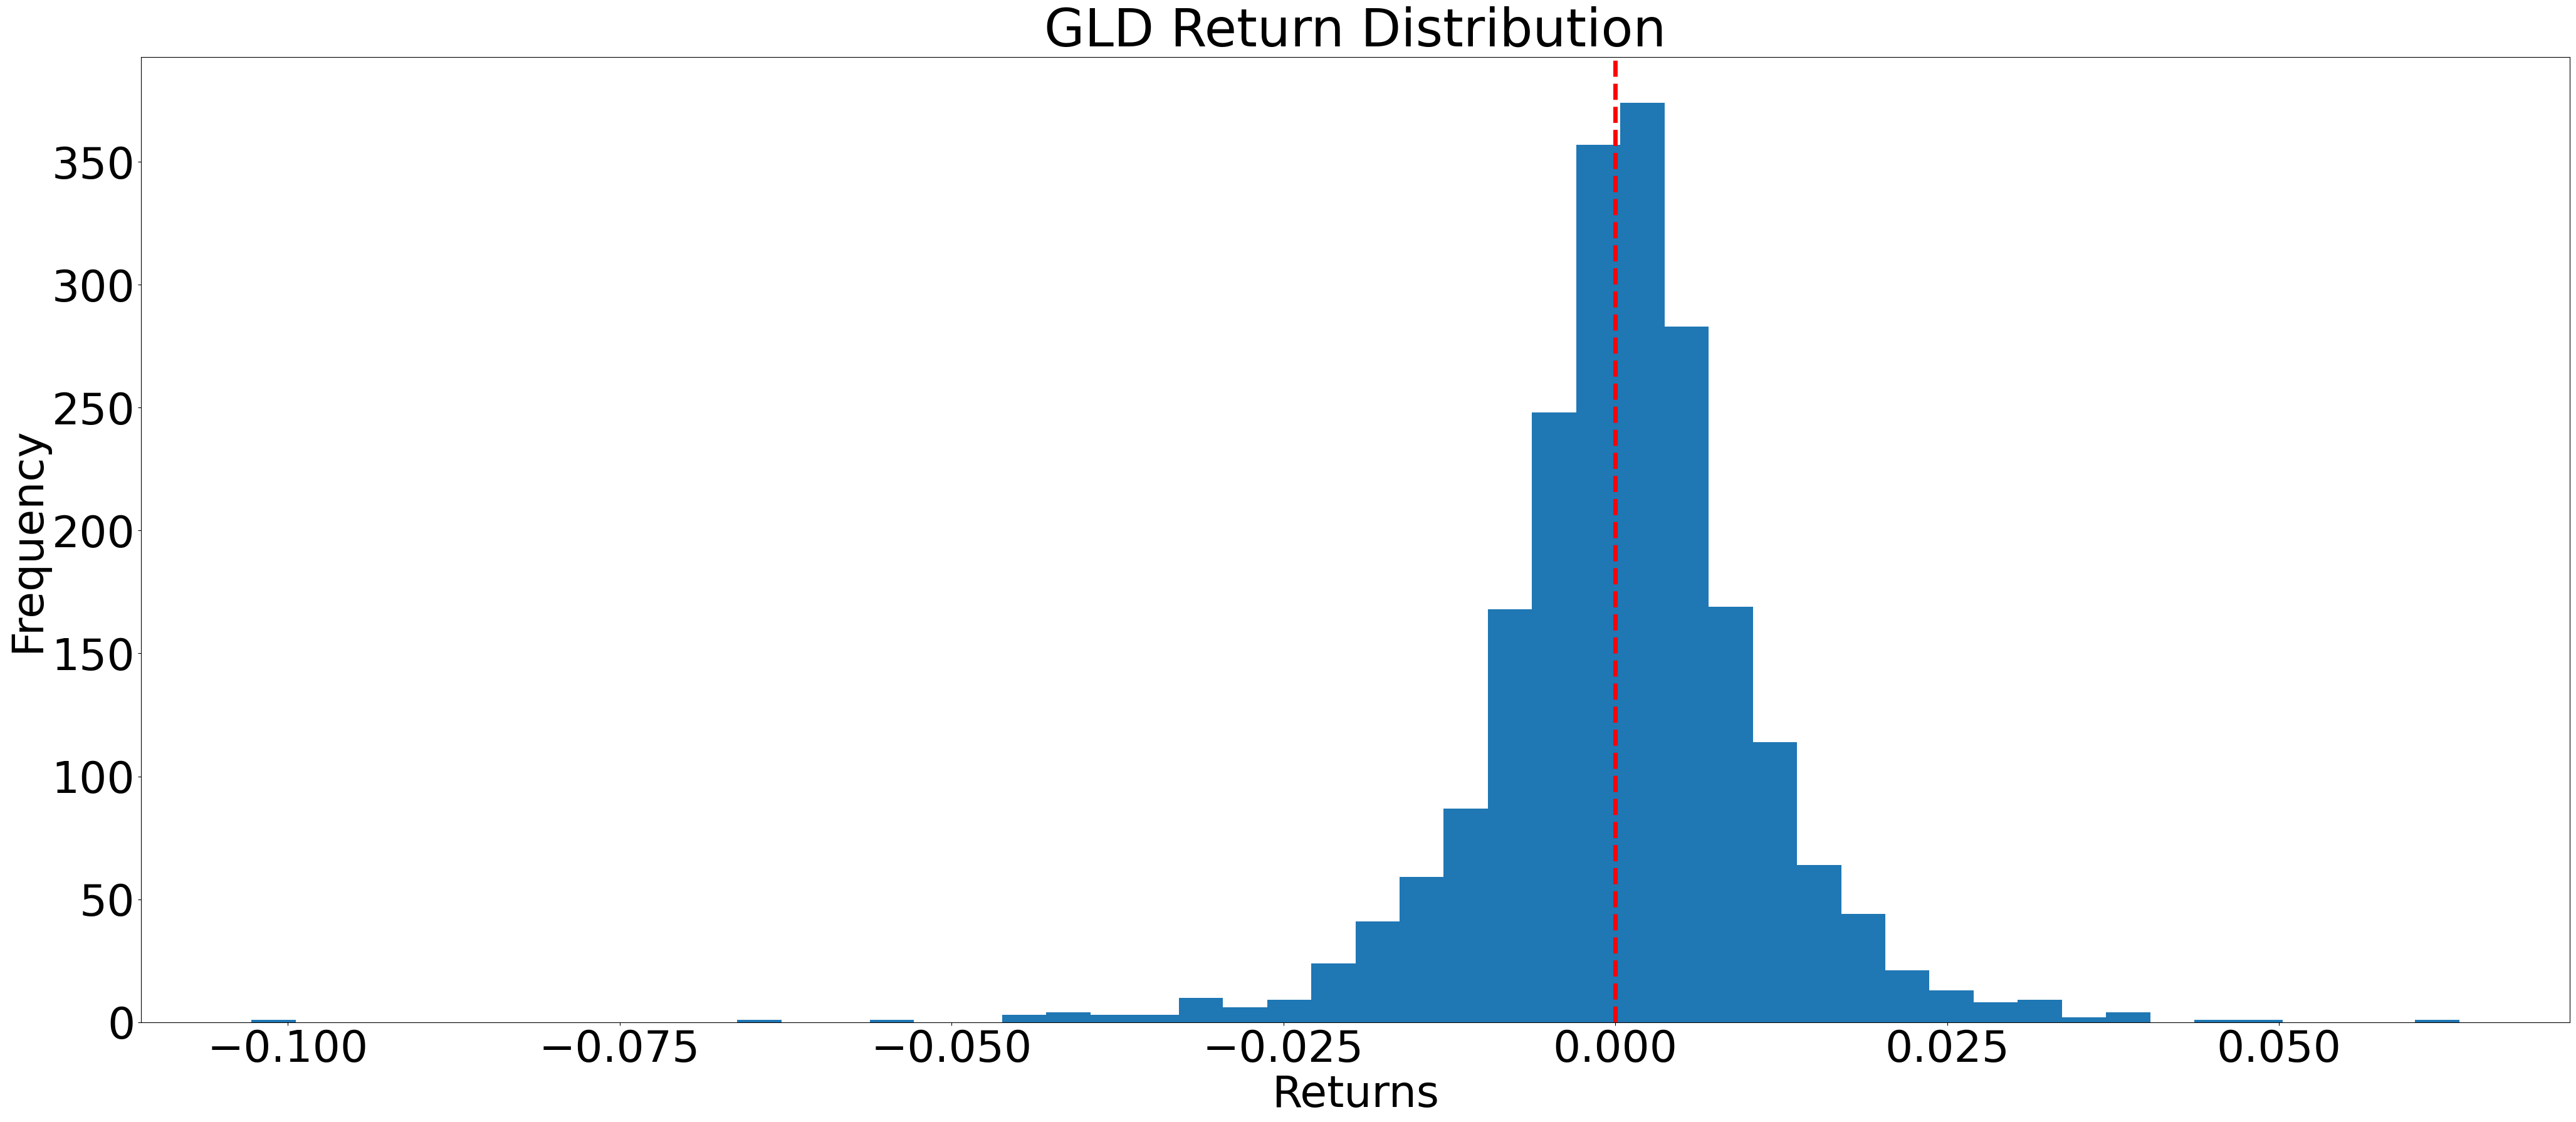

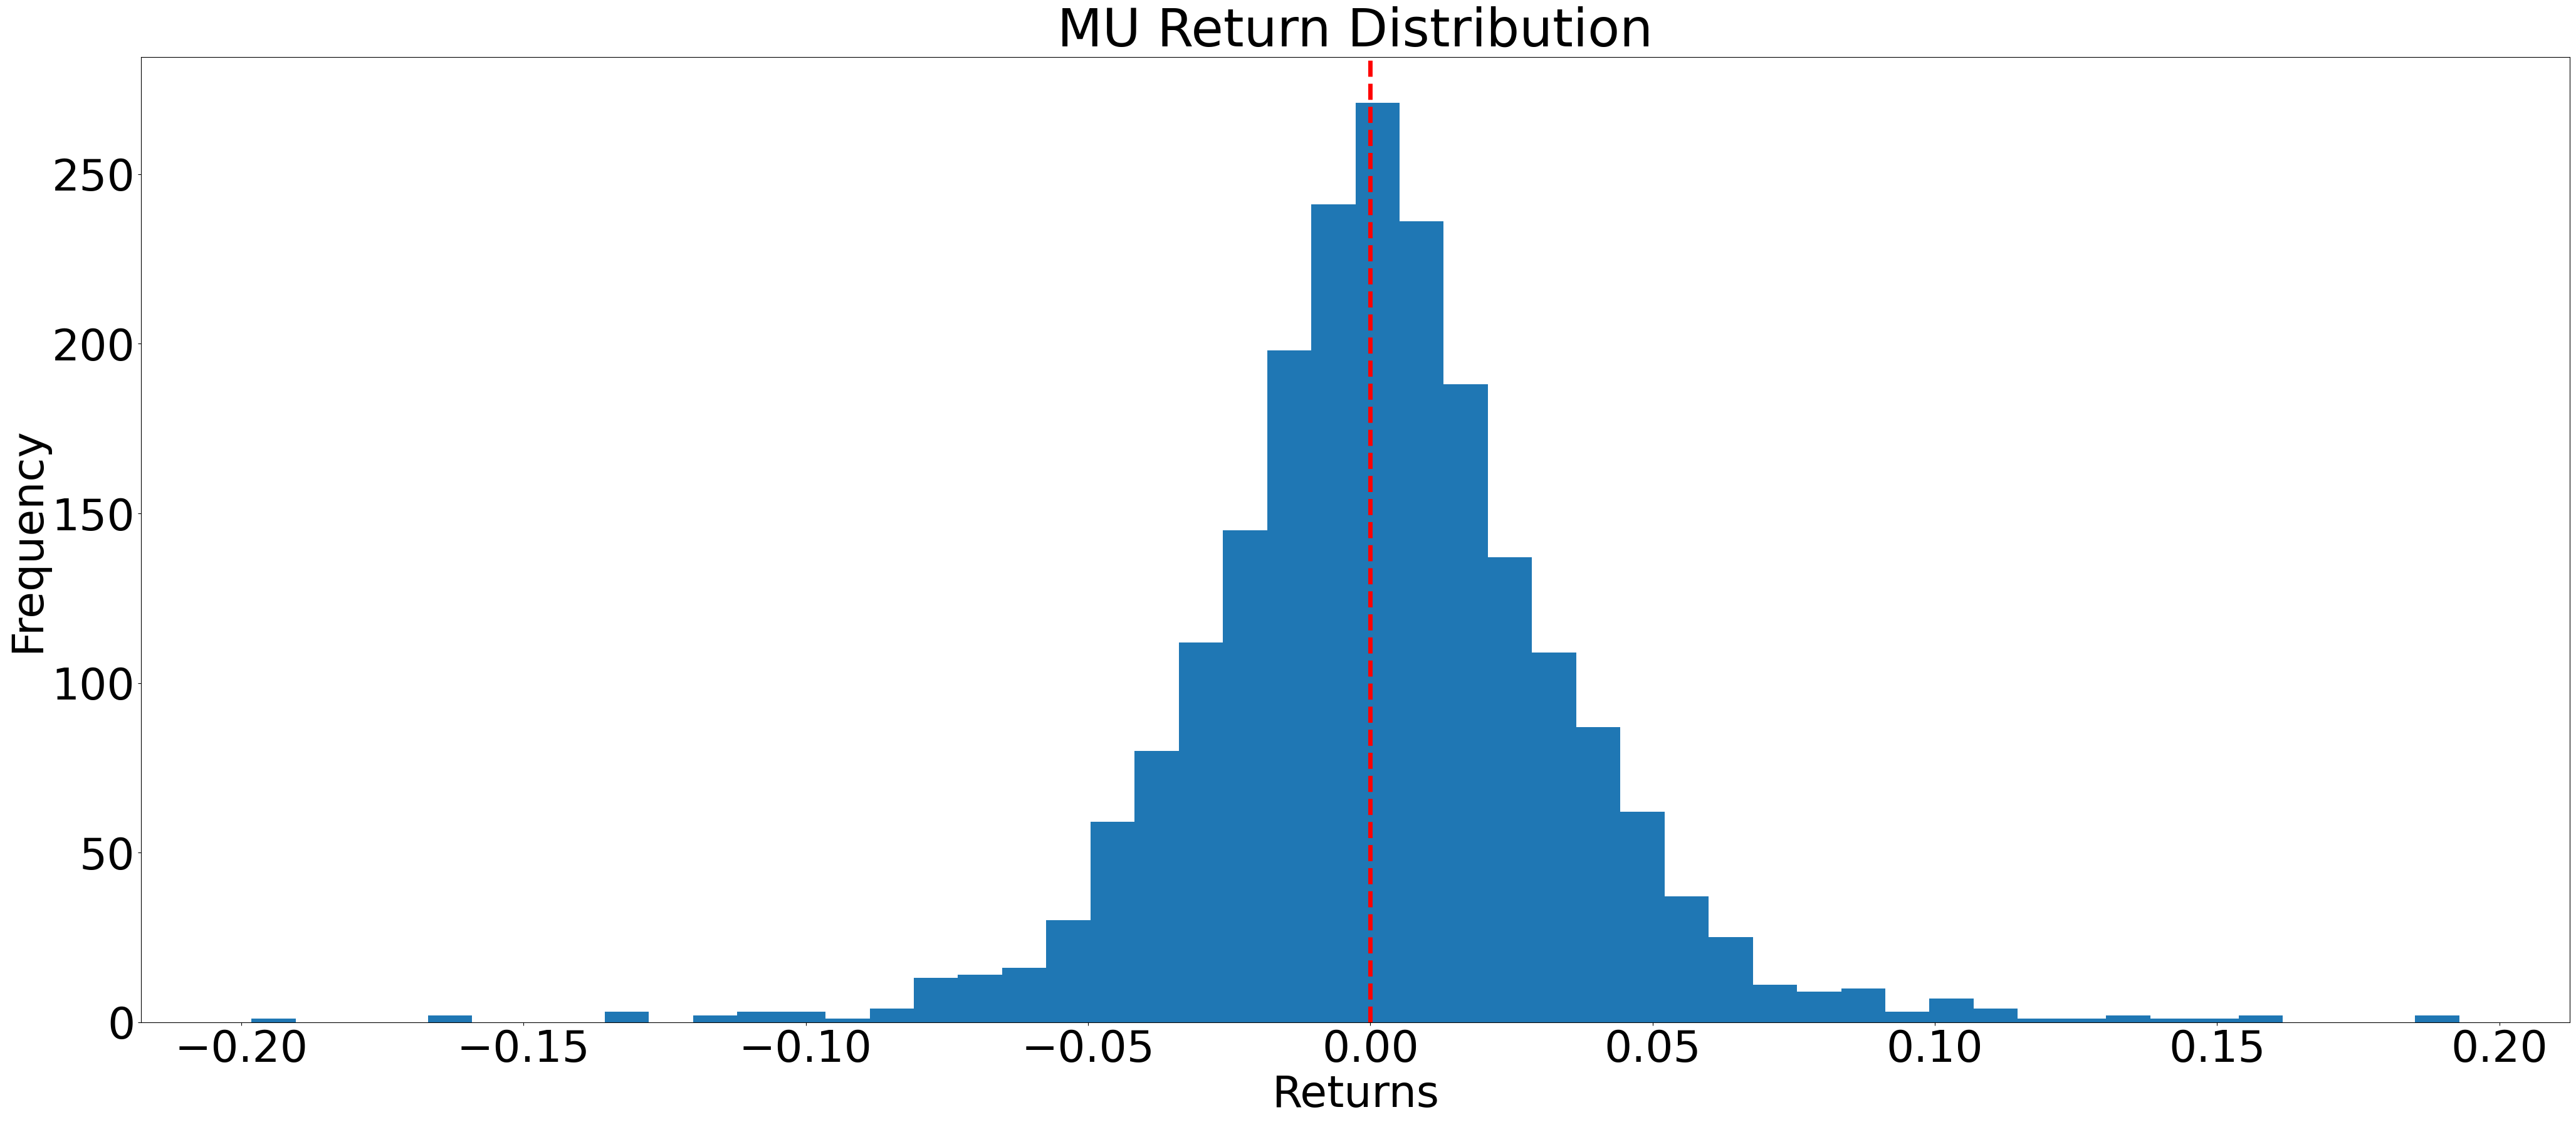

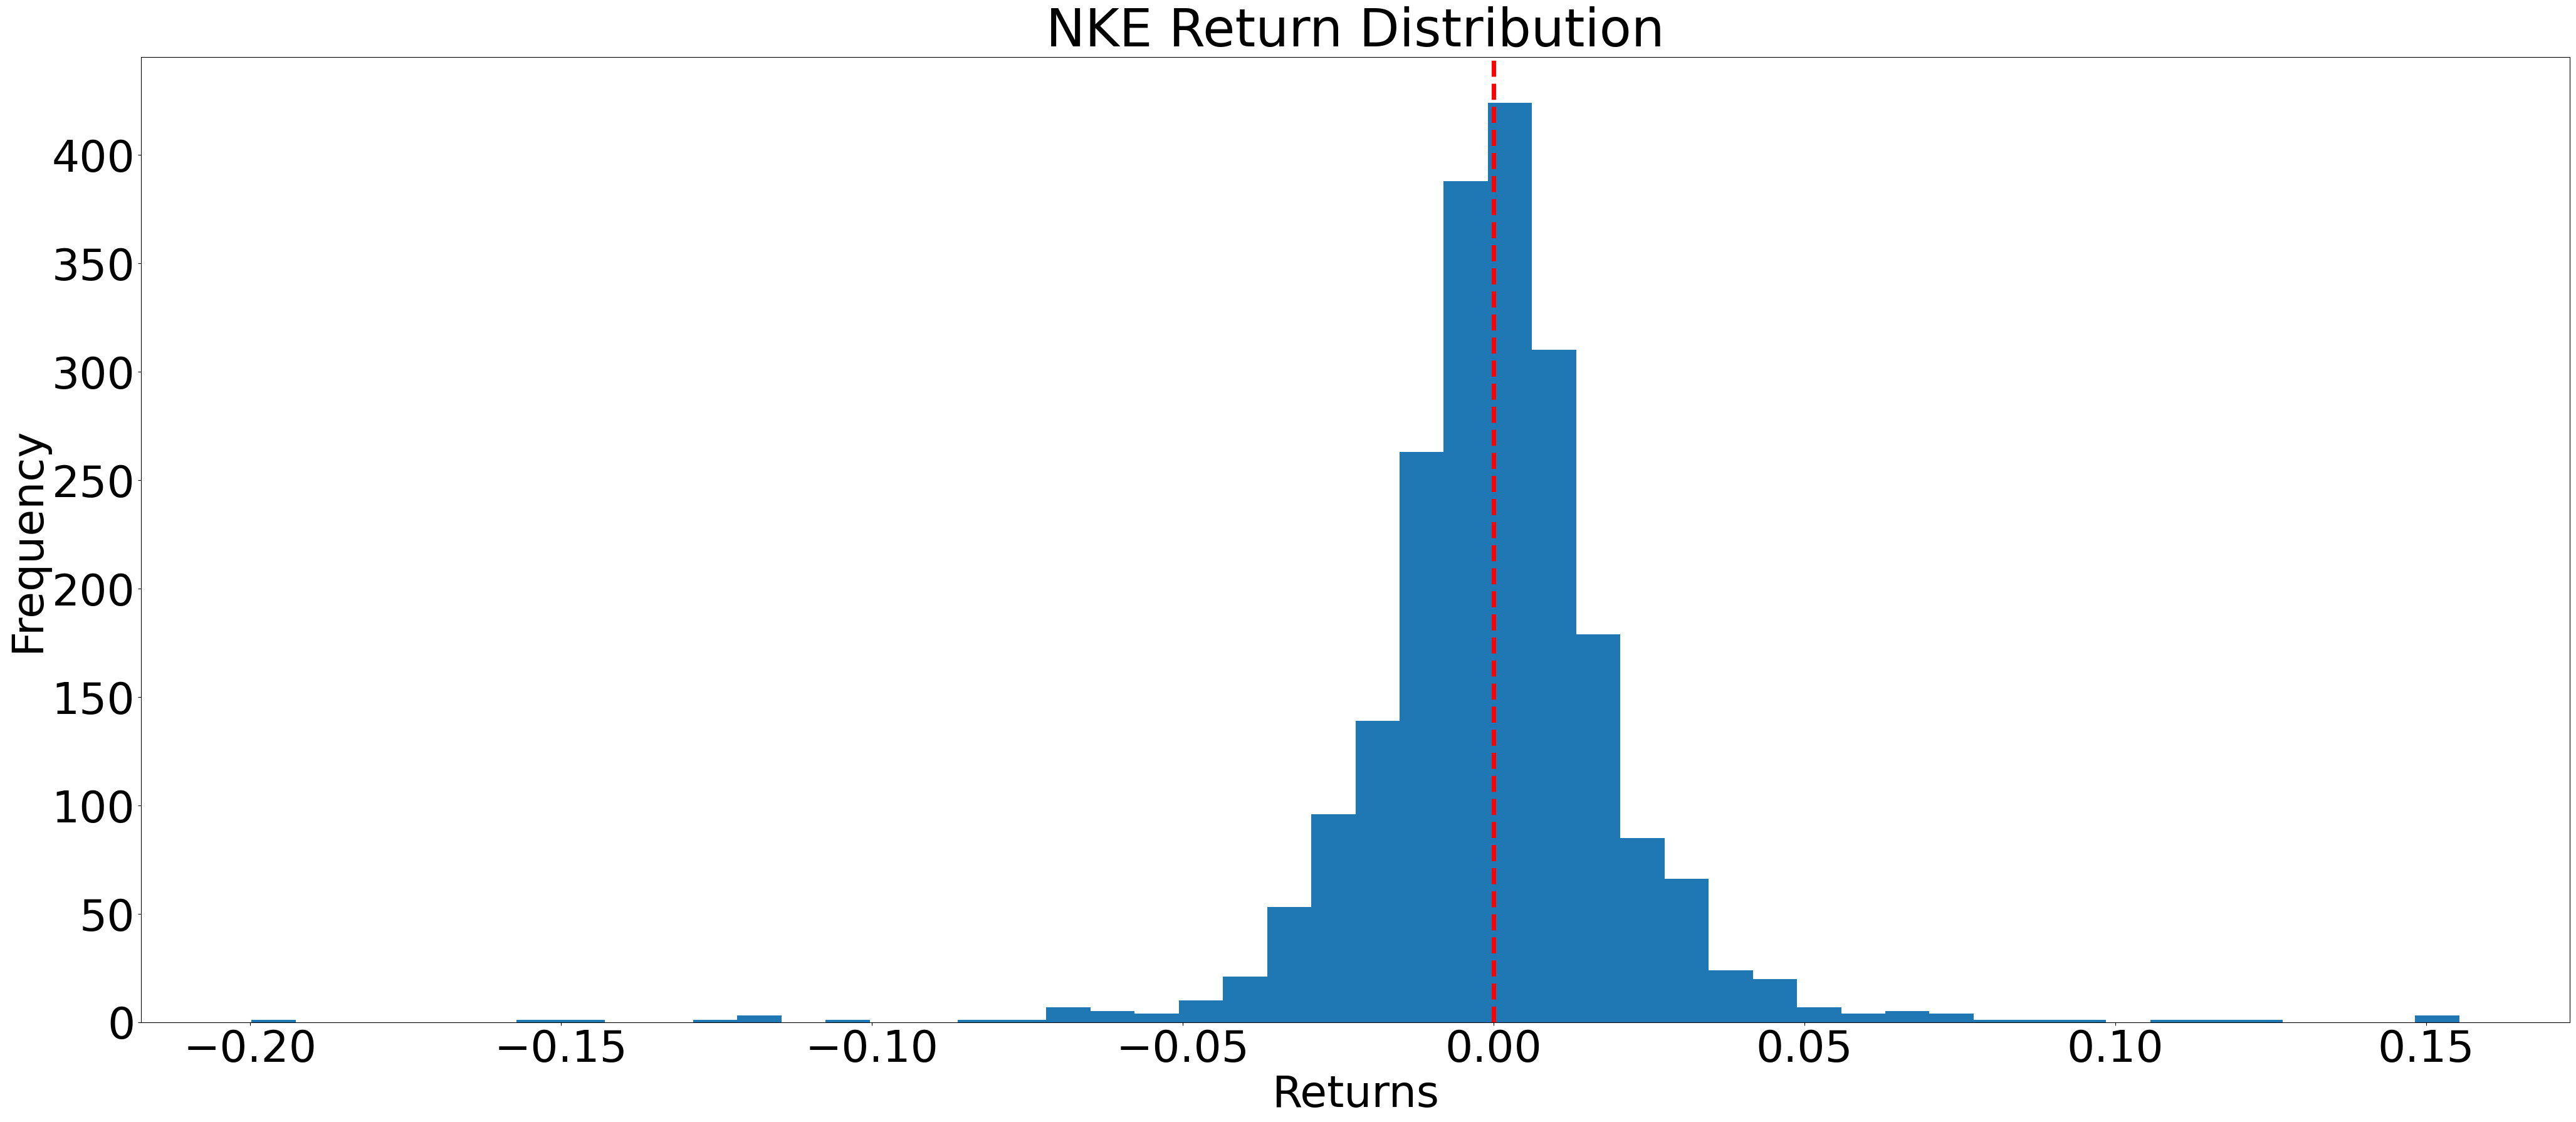

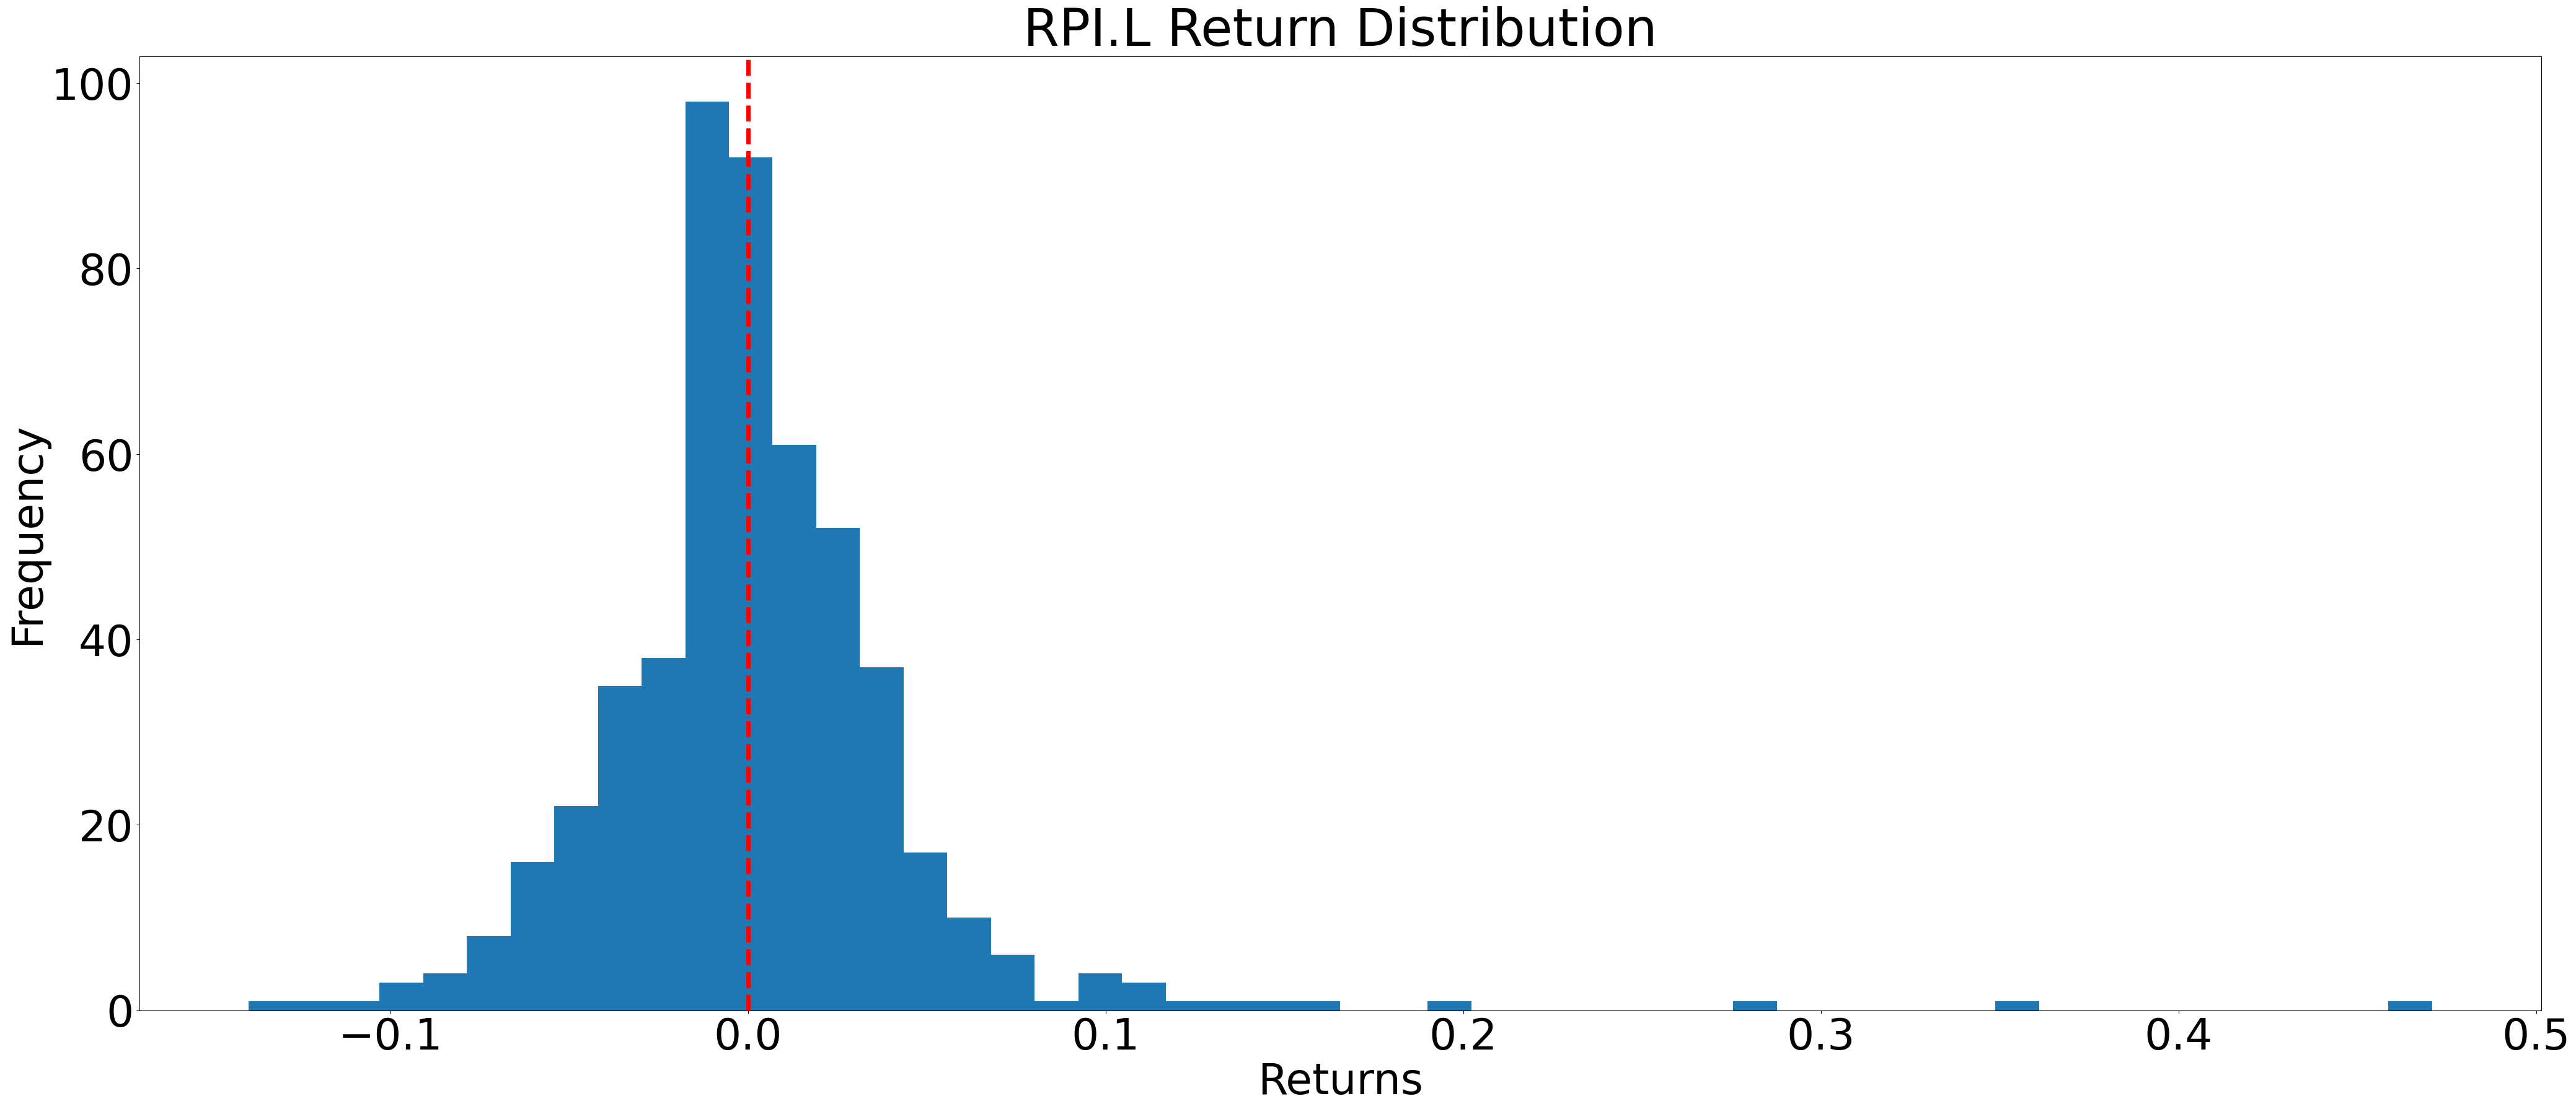

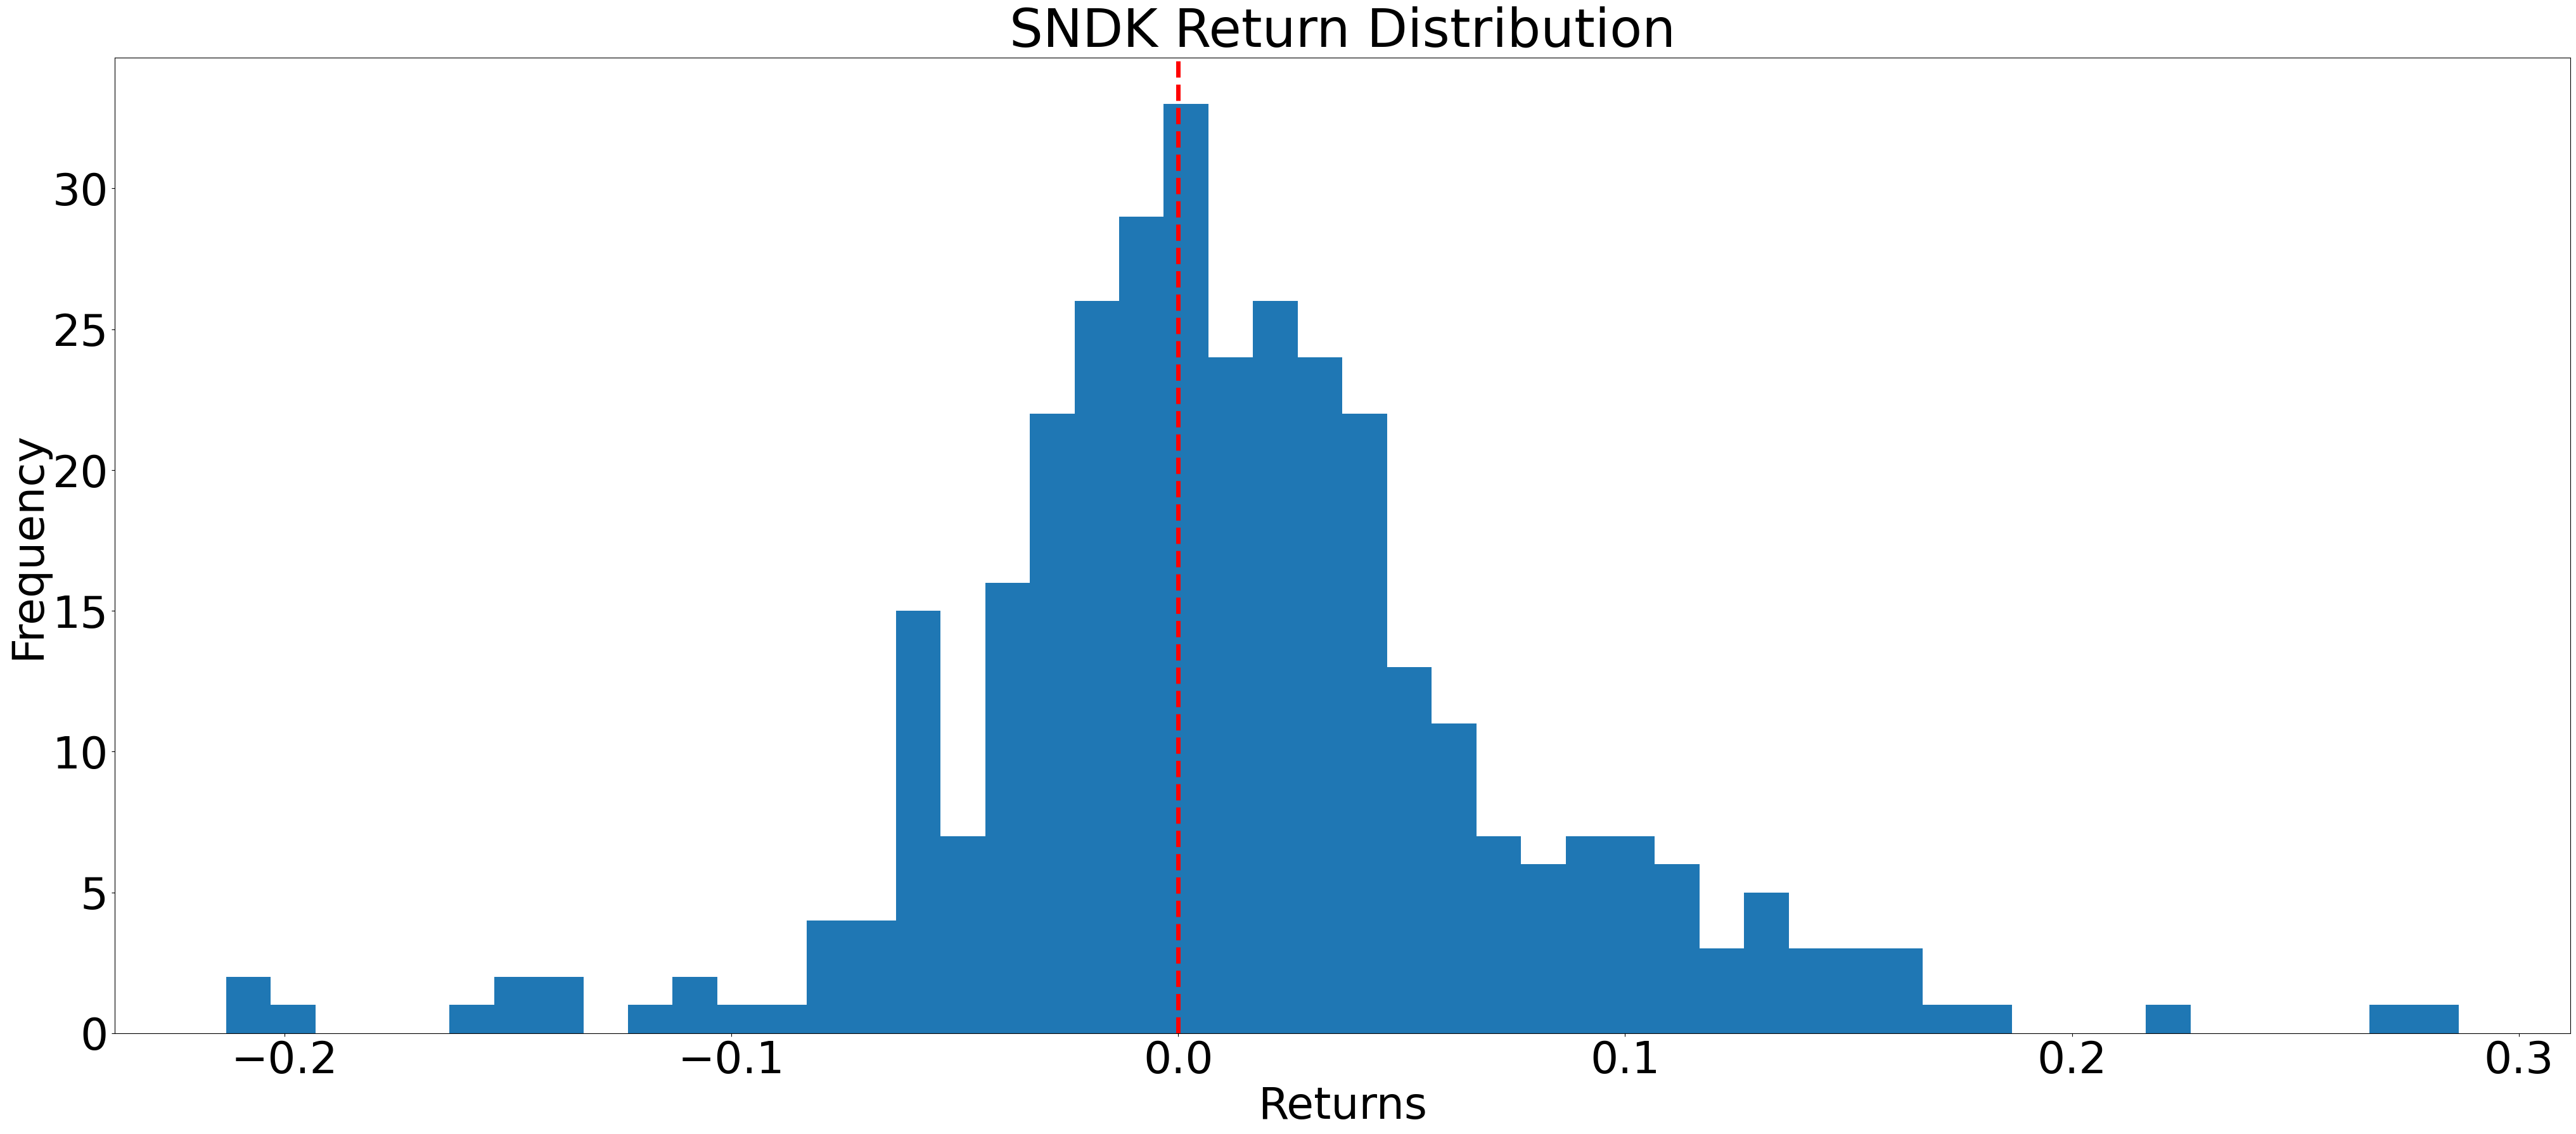

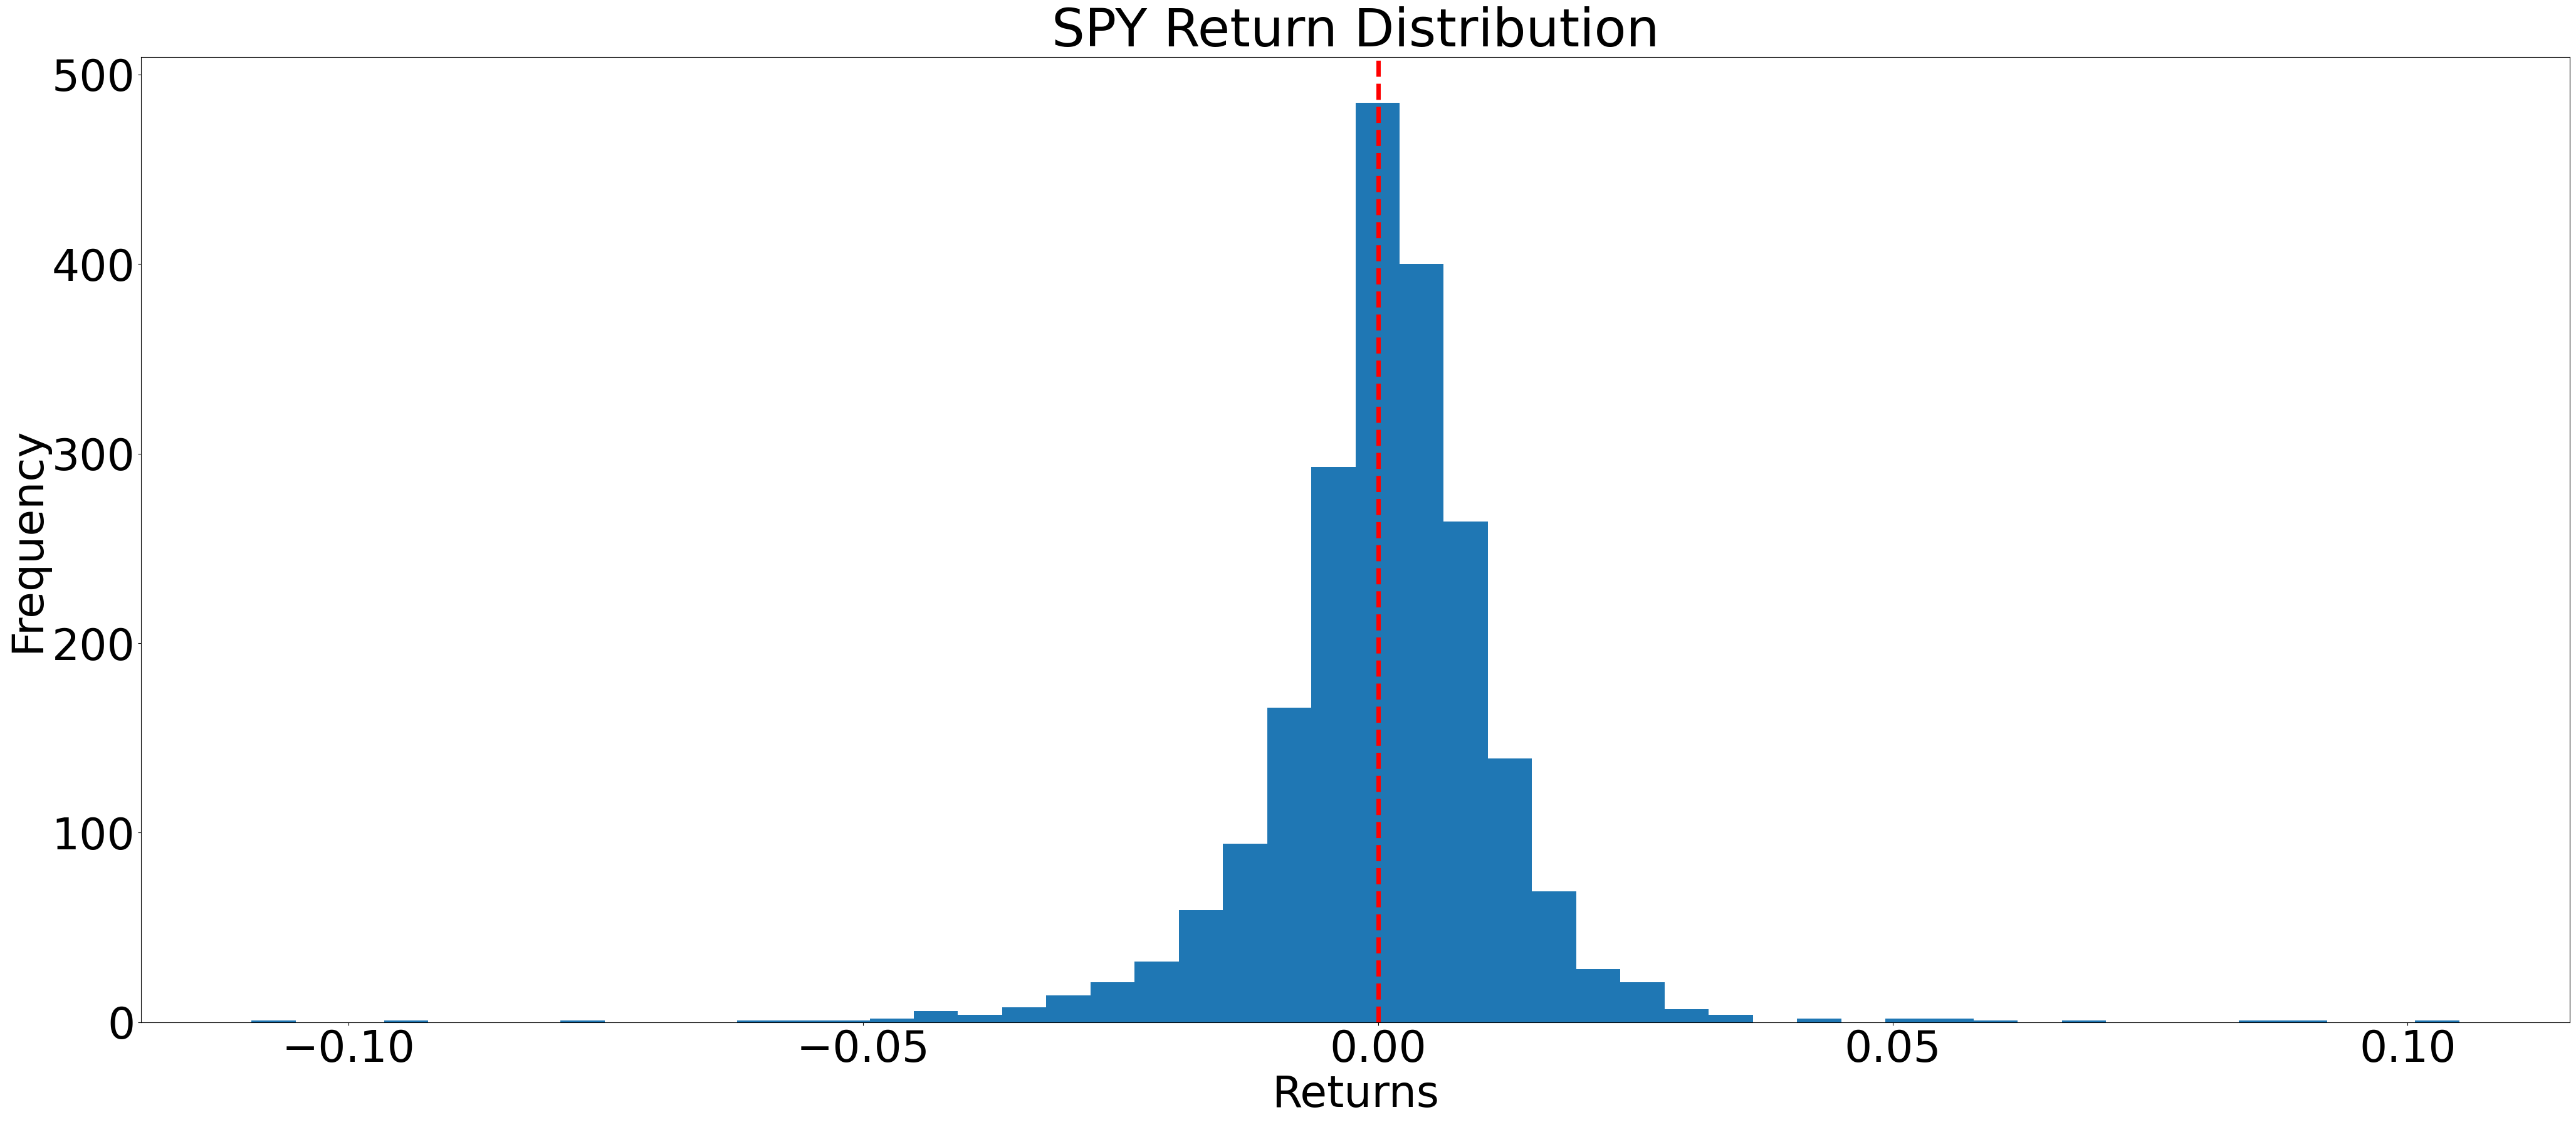

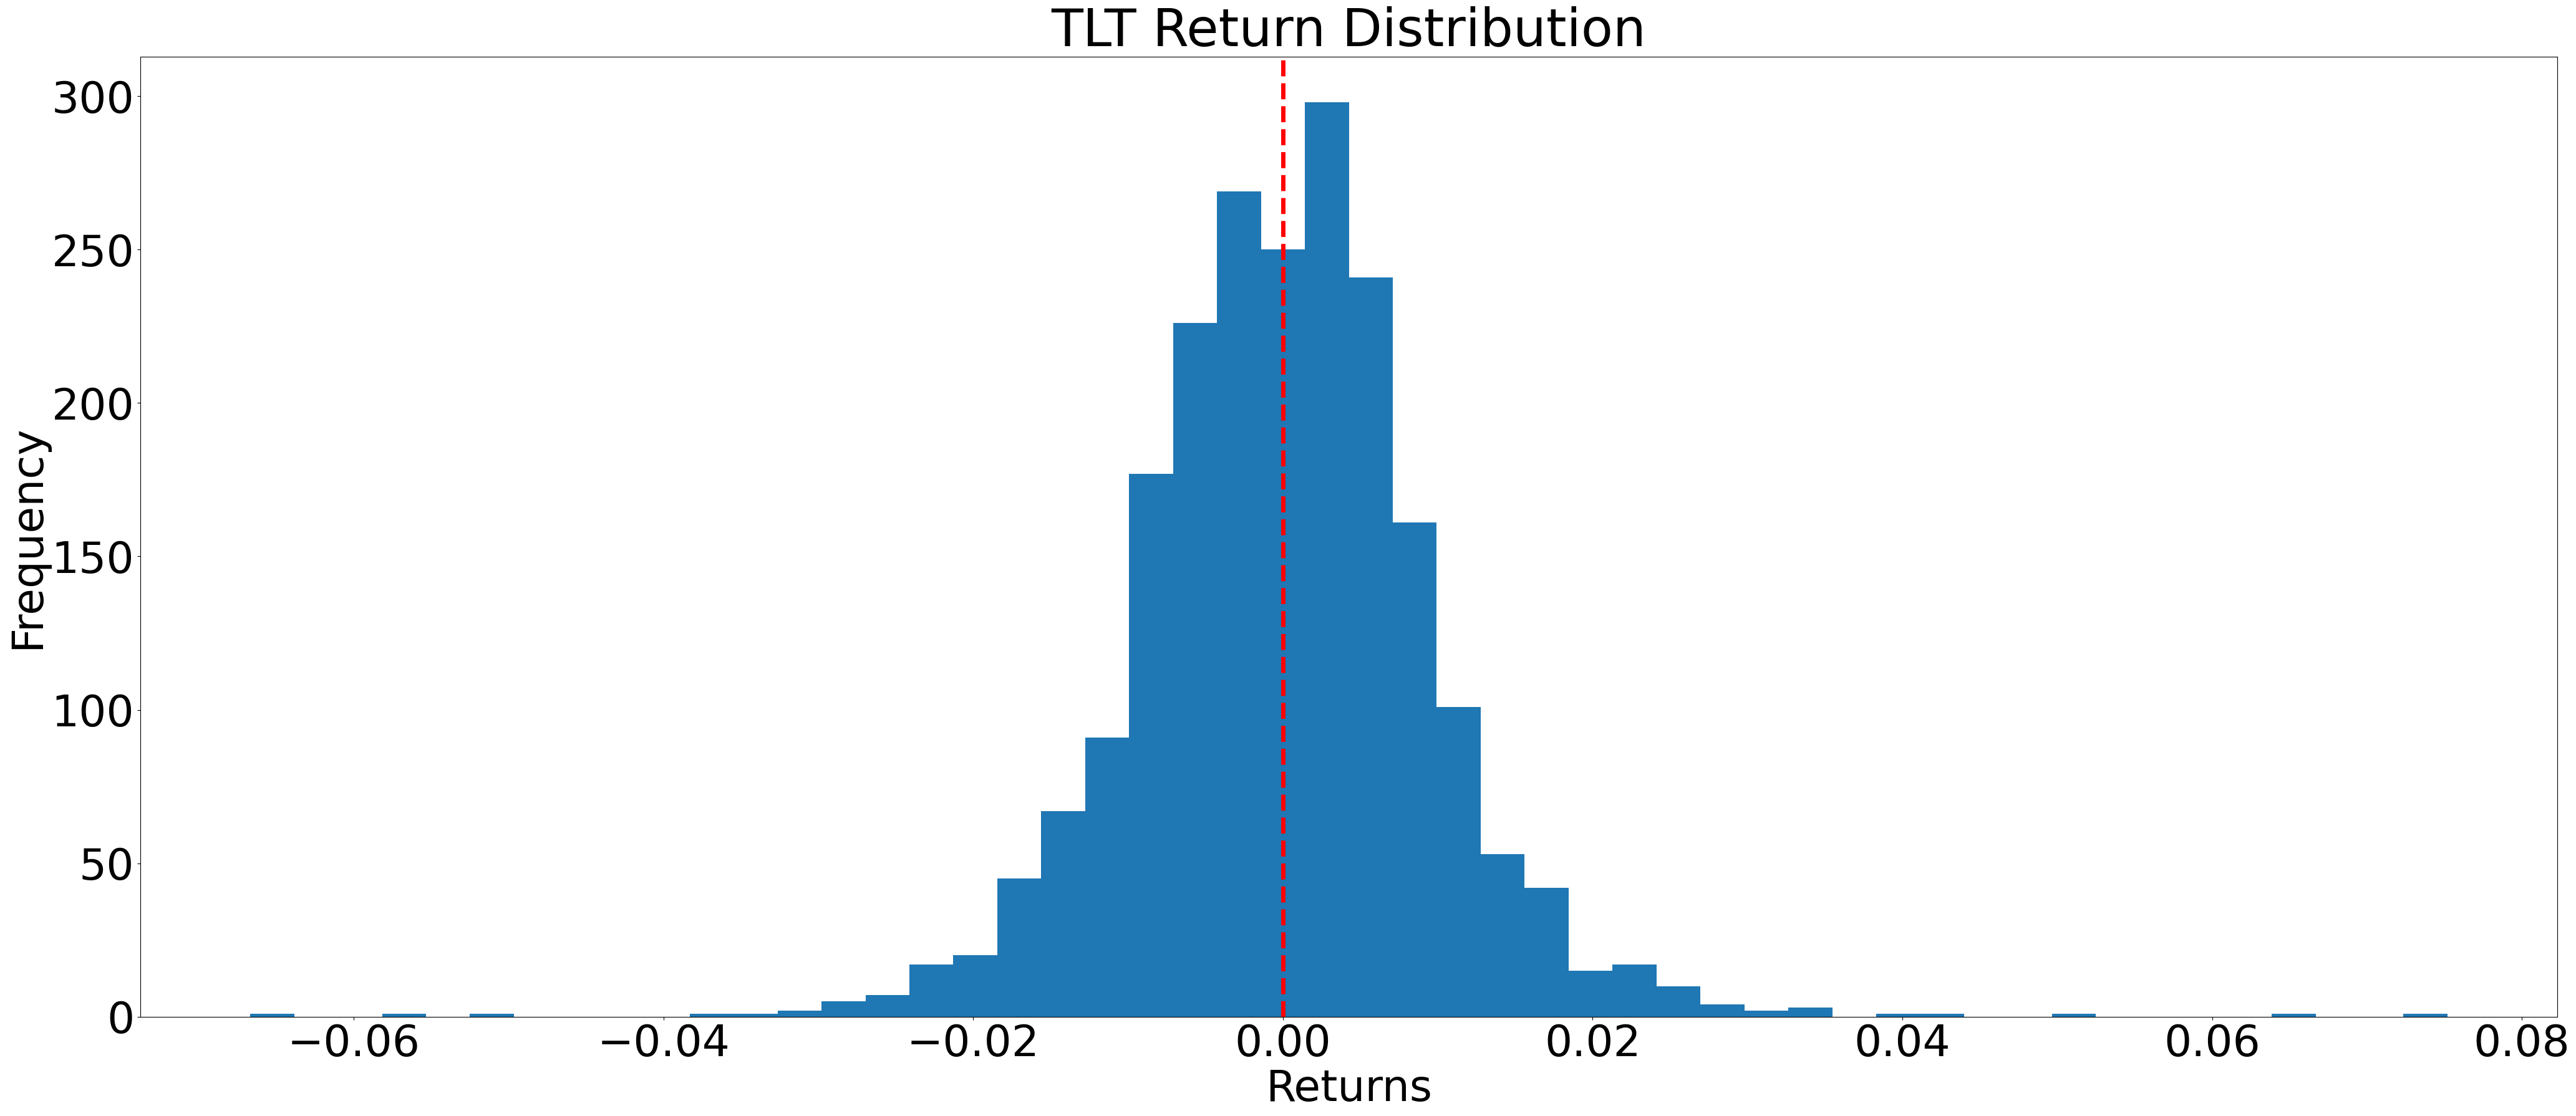

In [21]:
# Plot return distributions

import matplotlib.pyplot as plt

df = pull_calendar_table(
    table_name = "price_features",
    calendar = CALENDAR
)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["ticker", "date"])

daily_return = f"daily_return_{CALENDAR}"

for ticker, group in df.groupby("ticker"):
    returns = group[daily_return]
    plt.figure(figsize=(50,20))
    plt.hist(returns.dropna(), bins=50)
    plt.title(f"{ticker} Return Distribution", fontsize = 60)
    plt.xticks(fontsize=50)
    plt.yticks(fontsize=50)
    plt.xlabel("Returns", fontsize = 50)
    plt.ylabel("Frequency", fontsize = 50)
    plt.axvline(0, linestyle = "--", color = "red", linewidth = "5")
    plt.show()

In [22]:
# Compare average daily returns and volatility by ticker

df = pull_calendar_table(
    table_name = "price_features",
    calendar = CALENDAR
)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["ticker", "date"])

daily_return = f"daily_return_{CALENDAR}"

summary = (
    df.groupby("ticker")[daily_return]
    .agg(
        average_daily_return="mean",
        volatility="std",
        observations="count"
    )
)

summary_pct = summary.copy()

summary_pct["average_daily_return"] = summary_pct["average_daily_return"] * 100
summary_pct["volatility"] = summary_pct["volatility"] * 100

summary_pct = summary_pct.sort_values("average_daily_return", ascending=False)

summary_pct


[START] Connecting to database...
[START] Reading price_features
[DONE] Read price_features
[START] Building no_calendar required columns...
[DONE] Filtered to no_calendar


,average_daily_return,volatility,observations
ticker,,,
SNDK,1.411833,6.432743,344
RPI.L,0.249870,4.739403,518
MU,0.209082,3.310103,2133
SPY,0.061367,1.209078,2133
GLD,0.056448,1.058841,2133
NKE,0.008651,2.138669,2133
TLT,-0.001260,0.973838,2133


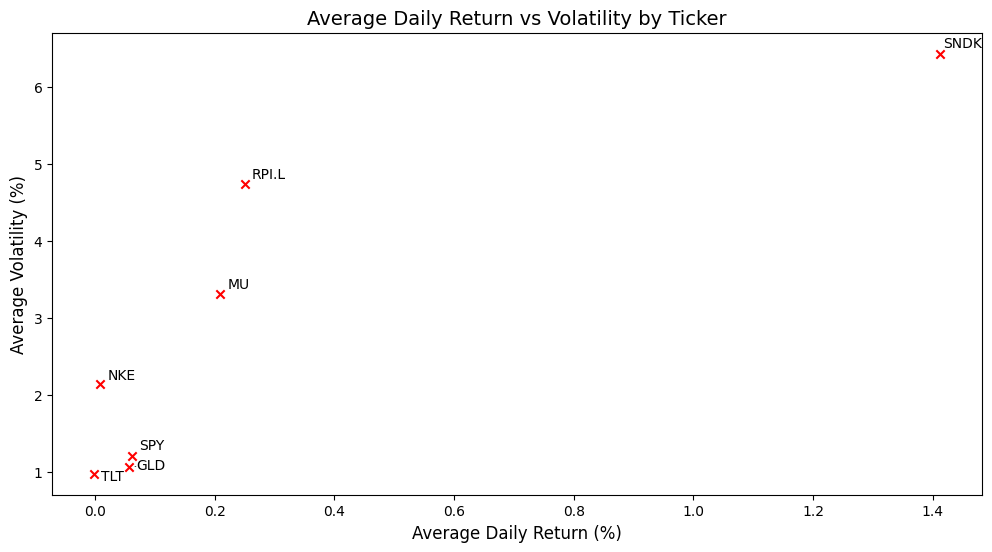

In [23]:
import matplotlib.pyplot as plt
from adjustText import adjust_text

plt.figure(figsize=(12,6))

plt.scatter(
    summary_pct["average_daily_return"],
    summary_pct["volatility"],
    marker = "x",
    color = "red"
    
)

texts = []
for ticker in summary_pct.index:
    texts.append(
        plt.text(
            0.01 + summary_pct.loc[ticker, "average_daily_return"],
            0.01 + summary_pct.loc[ticker, "volatility"],
            ticker
        )
    )

adjust_text(
    texts,
    x=summary_pct["average_daily_return"],
    y=summary_pct["volatility"],
    arrowprops=dict(arrowstyle="-", lw=0.5)
)


plt.ylabel("Average Volatility (%)", fontsize=12)
plt.xlabel("Average Daily Return (%)", fontsize=12)
plt.title("Average Daily Return vs Volatility by Ticker", fontsize=14)

plt.show()

In [24]:
# Identify extreme return days

# 1. Table view
df = pull_calendar_table(
    table_name = "price_features",
    calendar = CALENDAR
)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["ticker", "date"])

daily_return = f"daily_return_{CALENDAR}"

df["return_mean"] = df.groupby("ticker")[daily_return].transform("mean")

df["return_std"] = df.groupby("ticker")[daily_return].transform("std")

df["return_zscore"] = (
    (df[daily_return] - df["return_mean"]) / df["return_std"]
)

extreme_days = df[df["return_zscore"].abs() > 3]

extreme_days_view = (
    extreme_days[
        ["ticker", "date", daily_return, "return_zscore"]
    ]
    .sort_values("return_zscore")
)

extreme_days_view

[START] Connecting to database...
[START] Reading price_features
[DONE] Read price_features
[START] Building no_calendar required columns...
[DONE] Filtered to no_calendar


,ticker,date,daily_return_no_calendar,return_zscore
10398,GLD,2026-01-30,-0.102742,-9.756602
10857,NKE,2024-06-28,-0.199809,-9.346718
3860,SPY,2020-03-16,-0.109424,-9.100925
11073,SPY,2020-03-12,-0.095677,-7.963997
6525,NKE,2026-04-01,-0.155055,-7.254108
...,...,...,...,...
6710,SPY,2020-03-24,0.090603,7.442831
10968,RPI.L,2026-02-17,0.360656,7.557008
4123,TLT,2020-03-20,0.075196,7.722881
8275,SPY,2025-04-09,0.105019,8.635152


In [25]:
# 2. Count by ticker
extreme_counts = (
    extreme_days
    .groupby("ticker")
    .size()
    .sort_values(ascending=False)
)

extreme_counts

ticker
NKE      34
MU       32
GLD      29
SPY      29
TLT      17
SNDK      6
RPI.L     6
dtype: int64

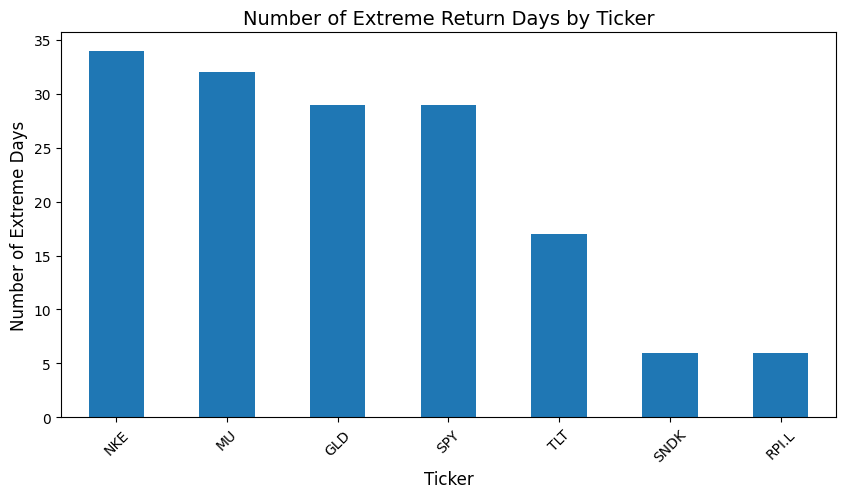

In [26]:
# 3. Bar plot of counts
plt.figure(figsize=(10, 5))

extreme_counts.plot(kind="bar")

plt.title("Number of Extreme Return Days by Ticker", fontsize=14)
plt.xlabel("Ticker", fontsize=12)
plt.ylabel("Number of Extreme Days", fontsize=12)

plt.xticks(rotation=45)
plt.show()

In [27]:
# Check skewness/kurtosis if you want extra depth

daily_return = f"daily_return_{CALENDAR}"

distribution_summary = (
    df.groupby("ticker")[daily_return]
      .agg(
          mean_return="mean",
          volatility="std",
          skewness="skew",
          kurtosis="kurt",
          observations="count"
      )
)

distribution_summary



,mean_return,volatility,skewness,kurtosis,observations
ticker,,,,,
GLD,0.000564,0.010588,-0.636367,7.305299,2133
MU,0.002091,0.033101,0.175578,3.593143,2133
NKE,0.000087,0.021387,-0.268748,12.821108,2133
RPI.L,0.002499,0.047394,3.267675,26.666113,518
SNDK,0.014118,0.064327,0.345475,2.506943,344
SPY,0.000614,0.012091,-0.294439,13.116533,2133
TLT,-0.000013,0.009738,0.161246,5.043367,2133


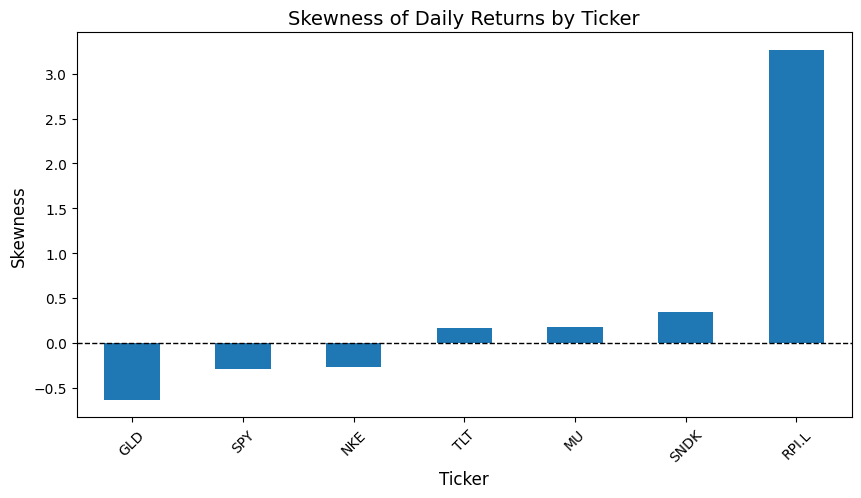

In [28]:
import matplotlib.pyplot as plt

skewness_by_ticker = distribution_summary["skewness"].sort_values()

plt.figure(figsize=(10, 5))

skewness_by_ticker.plot(kind="bar")

plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.title("Skewness of Daily Returns by Ticker", fontsize=14)
plt.xlabel("Ticker", fontsize=12)
plt.ylabel("Skewness", fontsize=12)

plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

plt.show()

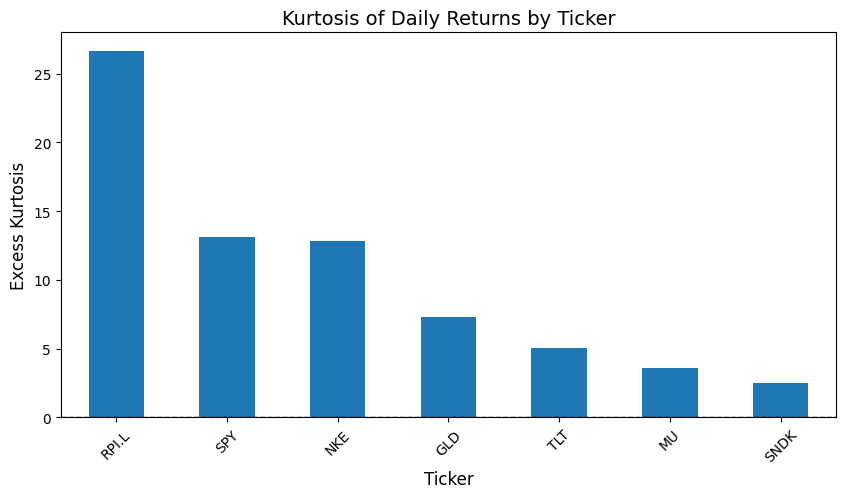

In [29]:
kurtosis_by_ticker = distribution_summary["kurtosis"].sort_values(ascending=False)

plt.figure(figsize=(10, 5))

kurtosis_by_ticker.plot(kind="bar")

plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.title("Kurtosis of Daily Returns by Ticker", fontsize=14)
plt.xlabel("Ticker", fontsize=12)
plt.ylabel("Excess Kurtosis", fontsize=12)

plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

plt.show()

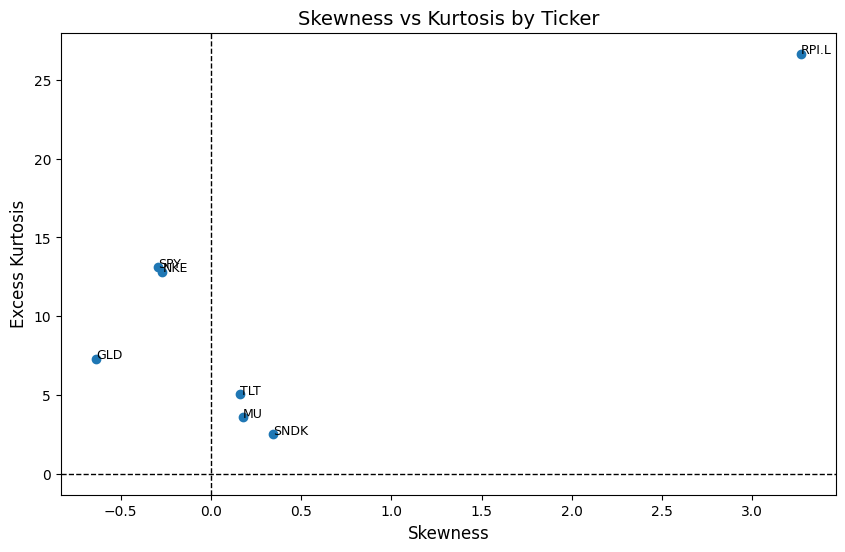

In [30]:
plt.figure(figsize=(10, 6))

plt.scatter(
    distribution_summary["skewness"],
    distribution_summary["kurtosis"]
)

for ticker in distribution_summary.index:
    plt.text(
        distribution_summary.loc[ticker, "skewness"],
        distribution_summary.loc[ticker, "kurtosis"],
        ticker,
        fontsize=9
    )

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.title("Skewness vs Kurtosis by Ticker", fontsize=14)
plt.xlabel("Skewness", fontsize=12)
plt.ylabel("Excess Kurtosis", fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.show()

5. Risk analysis
- [ ] Plot rolling volatility by ticker
- [ ] Identify periods of high volatility
- [ ] Calculate max drawdown by ticker
- [ ] Plot drawdown over time
- [ ] Compare risk across assets
- [ ] Write 2–3 observations

[START] Connecting to database...
[START] Reading price_features
[DONE] Read price_features
[START] Building no_calendar required columns...
[DONE] Filtered to no_calendar


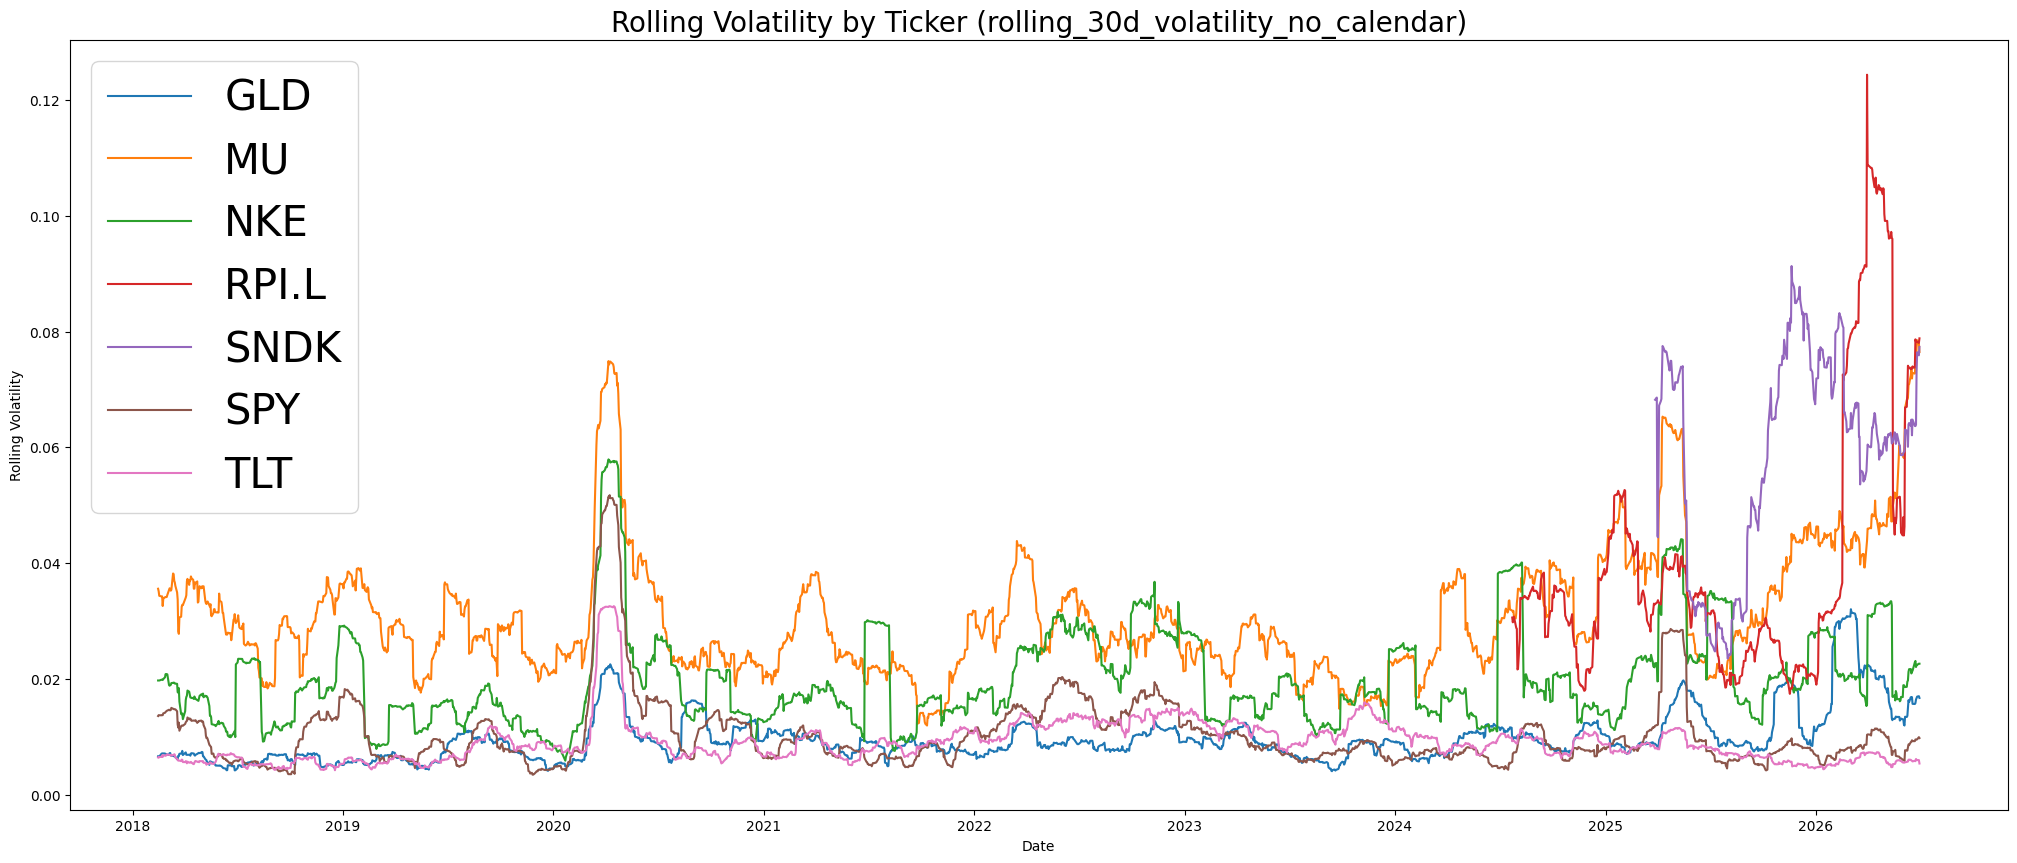

In [39]:
# Plot rolling volatility

df = pull_calendar_table(
    table_name = "price_features",
    calendar = CALENDAR
)

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["ticker", "date"])

df_volatility = df.columns[
    df.columns.str.contains("volatility", case=False, na=False)
].to_list()

for vol_col in df_volatility:

    plt.figure(figsize=(25,10))

    for ticker, group in df.groupby("ticker"):
        plt.plot(group["date"], group[vol_col], label = ticker)

    plt.legend(fontsize = 30)
    plt.title(f"Rolling Volatility by Ticker ({vol_col})", fontsize = 20)
    plt.xlabel("Date")
    plt.ylabel("Rolling Volatility")
    plt.show()

[START] Connecting to database...
[START] Reading price_features
[DONE] Read price_features
[START] Building no_calendar required columns...
[DONE] Filtered to no_calendar
  ticker max_drawdown_date  max_drawdown max_drawdown_pct
0    GLD        2026-06-24     -0.262109          -26.21%
1     MU        2025-04-04     -0.576290          -57.63%
2    NKE        2026-06-26     -0.751048          -75.10%
3  RPI.L        2026-02-04     -0.664230          -66.42%
4   SNDK        2025-04-22     -0.475009          -47.50%
5    SPY        2020-03-23     -0.337173          -33.72%
6    TLT        2023-10-19     -0.483511          -48.35%


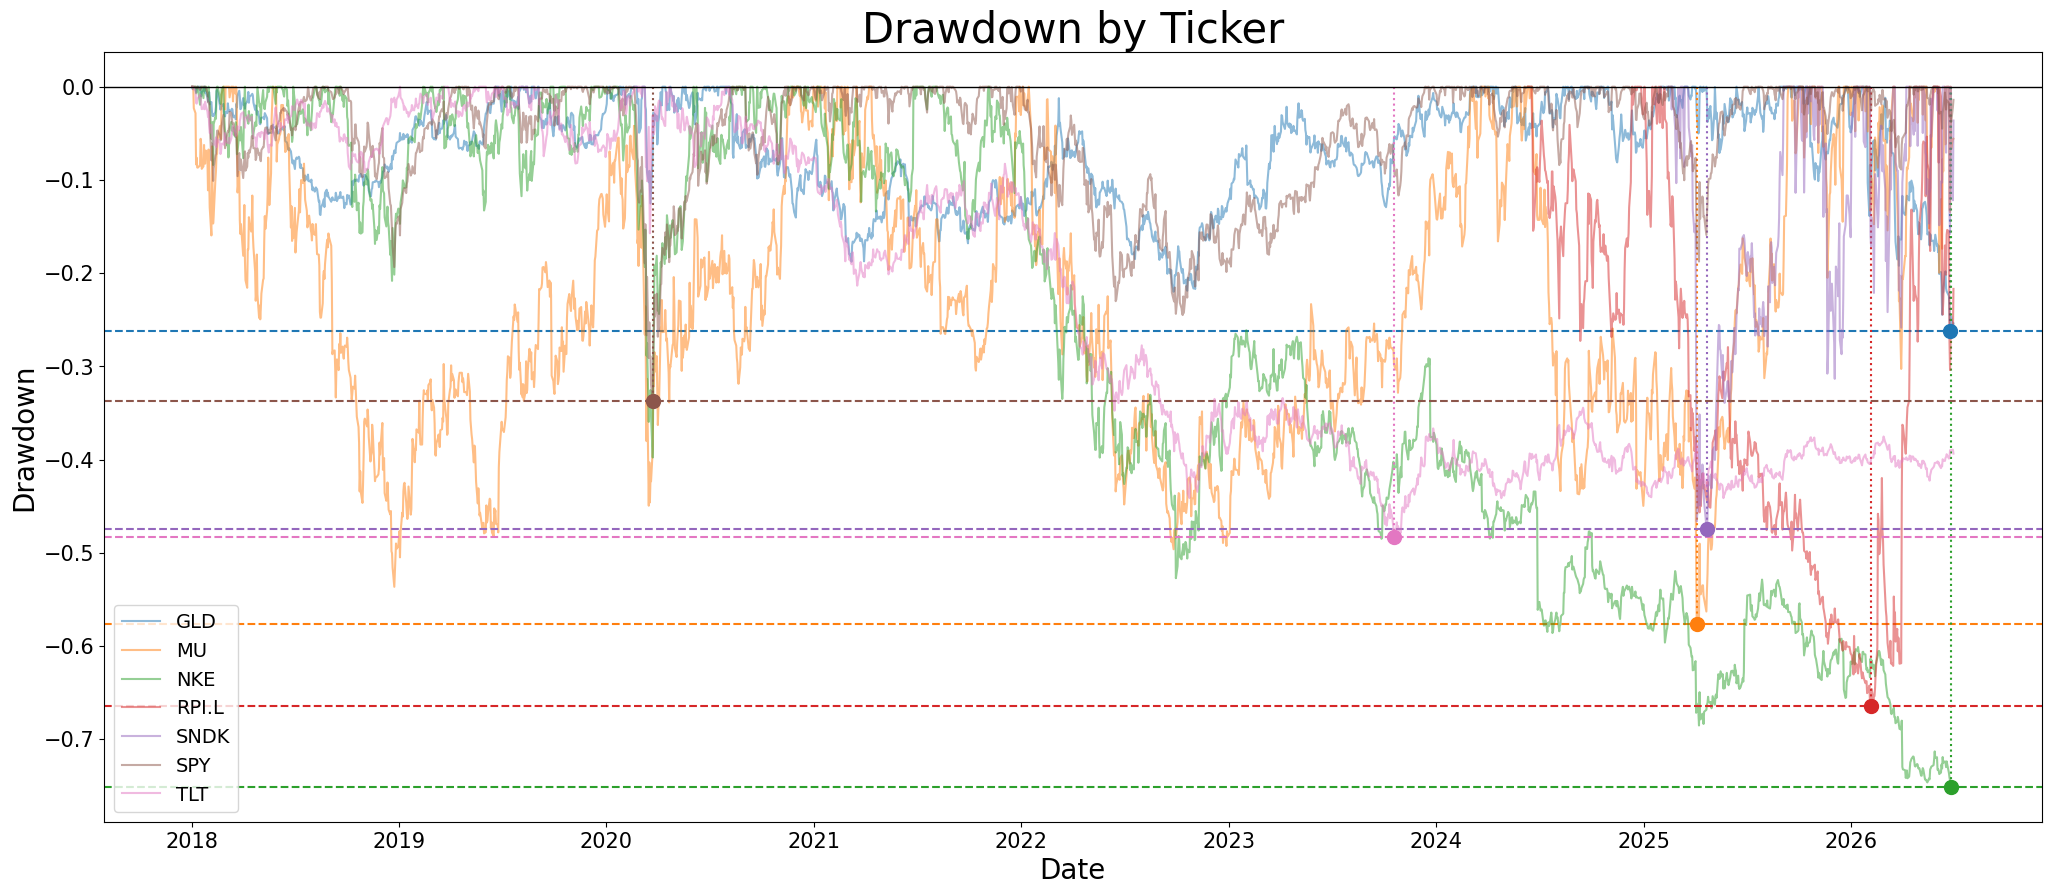

In [69]:
# Calculate maxdrawdown by ticker

df = pull_calendar_table(
    table_name = "price_features",
    calendar = CALENDAR
)

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["ticker", "date"])

drawdown_col = f"drawdown_{CALENDAR}"

max_dd_table = (
    df.loc[df.groupby("ticker")[drawdown_col].idxmin(), ["ticker", "date", drawdown_col]]
    .rename(columns = {
        "date": "max_drawdown_date",
        drawdown_col: "max_drawdown"
    }).reset_index(drop=True)
)

max_dd_table["max_drawdown_pct"] = max_dd_table["max_drawdown"].map(lambda x: f"{x:.2%}")

print(max_dd_table)

plt.figure(figsize = (25, 10))

for ticker, group in df.groupby("ticker"):
    group = group.sort_values("date")
    
    # Plot drawdown series
    line, = plt.plot(group["date"], group[drawdown_col], label=ticker, alpha = 0.5)
    colour = line.get_color()
    
    # Row index of max drawdown point (most negative value)
    max_dd_idx = group[drawdown_col].idxmin()
    
    # Get date and value of max drawdown
    max_dd_date = df.loc[max_dd_idx, "date"]
    max_dd_value = df.loc[max_dd_idx, drawdown_col]
    
    # Horizontal line at max drawdown level
    plt.axhline(
        y=max_dd_value,
        color=colour,
        linestyle="--",
        linewidth=1.5,
        alpha=1
    )
    
    # Vertical line at max drawdown date
    plt.vlines(
        x=max_dd_date,
        ymin=0,
        ymax=max_dd_value,
        color=colour,
        linestyle=":",
        linewidth=1.5,
        alpha=1
    )
    
    # Dot at max drawdown point
    plt.scatter(
        max_dd_date,
        max_dd_value,
        color=colour,
        s=100,
        zorder=5
    )

plt.axhline(0, color="black", linewidth=1)

plt.title("Drawdown by Ticker", fontsize=30)
plt.xlabel("Date", fontsize=20)
plt.ylabel("Drawdown", fontsize=20)
plt.legend(fontsize=14)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.show()

In [72]:
df = pull_calendar_table(
    table_name = "price_features",
    calendar = CALENDAR
)

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["ticker", "date"])

volatility_cols = df.columns[
    df.columns.str.contains("volatility", case=False, na=False)
].to_list()

drawdown_cols = df.columns[
    df.columns.str.contains("drawdown", case=False, na=False)
].to_list()

summary_parts = []

# Volatility summaries
for col in volatility_cols:
    temp = (
        df.groupby("ticker")[col]
        .agg(["mean", "max"])
        .rename(columns={
            "mean": f"{col}_avg",
            "max": f"{col}_max"
        })
    )
    summary_parts.append(temp)

# Drawdown summaries
for col in drawdown_cols:
    temp = (
        df.groupby("ticker")[col]
        .agg(["min", "mean"])
        .rename(columns={
            "min": f"{col}_max_drawdown",
            "mean": f"{col}_avg_drawdown"
        })
    )
    summary_parts.append(temp)

risk_table = pd.concat(summary_parts, axis=1).reset_index()

# Add max drawdown dates
date_parts = []

for col in drawdown_cols:
    idx = df.groupby("ticker")[col].idxmin()
    
    temp = (
        df.loc[idx, ["ticker", "date"]]
        .set_index("ticker")
        .rename(columns={"date": f"{col}_max_drawdown_date"})
    )
    
    date_parts.append(temp)

if date_parts:
    drawdown_dates = pd.concat(date_parts, axis=1).reset_index()
    risk_table = risk_table.merge(drawdown_dates, on="ticker", how="left")

display_table = risk_table.copy()

# Format date columns
date_cols = [col for col in display_table.columns if "date" in col.lower()]

for col in date_cols:
    display_table[col] = pd.to_datetime(display_table[col]).dt.strftime("%Y-%m-%d")

# Rename columns for display
display_table = display_table.rename(
    columns=lambda x: (
        x.replace("_", " ")
         .replace("avg", "Average")
         .replace("max", "Max")
         .replace("min", "Min")
         .title()
    )
)

display_table


[START] Connecting to database...
[START] Reading price_features
[DONE] Read price_features
[START] Building no_calendar required columns...
[DONE] Filtered to no_calendar


,Ticker,Rolling 30D Volatility No Calendar Average,Rolling 30D Volatility No Calendar Max,Drawdown No Calendar Max Drawdown,Drawdown No Calendar Average Drawdown,Drawdown No Calendar Max Drawdown Date
0,GLD,0.009651,0.032041,-0.262109,-0.068834,2026-06-24
1,MU,0.030677,0.078493,-0.576290,-0.228375,2025-04-04
2,NKE,0.019770,0.057918,-0.751048,-0.273642,2026-06-26
3,RPI.L,0.040390,0.124341,-0.664230,-0.314874,2026-02-04
4,SNDK,0.058890,0.091301,-0.475009,-0.131877,2025-04-22
5,SPY,0.010360,0.051742,-0.337173,-0.049548,2020-03-23
6,TLT,0.009034,0.032577,-0.483511,-0.229125,2023-10-19
